## 기본 실행

### 라이브러리 임포트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 데이터
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt

### 기본 설정

In [3]:
# 출력 설정
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.expand_frame_repr', True)

### 데이터 로드

In [4]:
!rsync -ah --progress "/content/drive/MyDrive/공모전/Toss/toss/train.parquet" "/content/train.parquet"
!rsync -ah --progress "/content/drive/MyDrive/공모전/Toss/toss/test.parquet"  "/content/test.parquet"

train_data = pd.read_parquet('/content/train.parquet')
test_data  = pd.read_parquet('/content/test.parquet')

sending incremental file list
train.parquet
          8.79G 100%   54.99MB/s    0:02:32 (xfr#1, to-chk=0/1)
sending incremental file list
test.parquet
          1.28G 100%   52.10MB/s    0:00:23 (xfr#1, to-chk=0/1)


## EDA

### 데이터 확인

In [ ]:
# 데이터 로드 확인
print('train_data:', train_data.shape)
print('test_data:', test_data.shape)

train_data: (10704179, 119)
test_data: (1527298, 119)


In [5]:
# 빠른 스냅샷
print('columns count:', len(train_data.columns))
print('train_data sample:', train_data.columns.tolist()[:10], '\n')

print('train_data head:'"\n", train_data.head(), '\n')
print('test_data head:'"\n", test_data.head(), '\n')

columns count: 119
train_data sample: ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'seq', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4'] 

train_data head:
   gender age_group inventory_id day_of_week hour                                                                              seq  l_feat_1  l_feat_2  \
0    1.0       7.0           36           5   13  9,18,269,516,57,97,527,74,317,311,269,479,57,74,317,77,58,58,540,269,300,479...       1.0       2.0   
1    1.0       7.0            2           5   08  9,144,269,57,516,97,527,74,315,317,311,269,479,57,74,315,317,58,58,540,269,4...       2.0       2.0   
2    1.0       7.0           36           5   11  269,516,57,97,165,527,74,77,317,269,75,450,15,269,483,75,450,15,269,483,75,4...       1.0       2.0   
3    1.0       8.0           37           5   11  269,57,516,21,214,269,561,214,269,561,247,516,527,74,318,207,452,452,508,269...       2.0       2.0   
4    2.0       7.0           37           5   07  144,269,5

### 결측치 확인

In [6]:
# train_data info
print('train_data info:"\n"', train_data.info())

# 결측치 종합
print('train missing values sum:', train_data.isnull().sum().sum())

# 결측치 컬럼별 종합
print('train missing values:'"\n", train_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10704179 entries, 0 to 10704178
Columns: 119 entries, gender to clicked
dtypes: float32(112), int32(1), object(6)
memory usage: 5.0+ GB
train_data info:"
" None
train missing values sum: 2745337
train missing values:
 gender          17208
age_group       17208
inventory_id        0
day_of_week         0
hour                0
                ...  
history_b_27    17208
history_b_28    17208
history_b_29    17208
history_b_30    17208
clicked             0
Length: 119, dtype: int64


In [ ]:
# 총 결측치 비율
total_missing = train_data.isnull().sum().sum()
total_cells = train_data.shape[0] * train_data.shape[1]
print('missing ratio:',total_missing/total_cells*100)

# 높은 결측치 비율 컬럼
missing_pct = train_data.isnull().mean()*100
print('missing ratio top 67'"\n",
      missing_pct.sort_values(ascending=False).head(10))

missing ratio: 0.215523851231649
missing ratio top 67
 feat_e_3     10.141432
feat_a_3      0.173745
feat_a_4      0.173745
feat_a_5      0.173745
feat_a_6      0.173745
feat_a_18     0.173745
feat_a_17     0.173745
feat_a_9      0.173745
feat_a_10     0.173745
feat_a_11     0.173745
dtype: float64


In [ ]:
# 결측이 여러 컬럼에서 동일한 row에 발생하는지 확인
cols = ['gender', 'age_group', 'feat_e_1', 'feat_e_2']
missing_df = train_data[cols].isna()

# 컬럼별 결측 row 수 확인
print('missing_count')
print(missing_df.sum())

# diff_count가 0인 경우 두 컬럼의 결측 위치가 동일함
for i, col1 in enumerate(cols):
    for col2 in cols[i + 1:]:
        diff_count = (missing_df[col1] != missing_df[col2]).sum()
        print(f"{col1} vs {col2}: {diff_count:,}")

missing_count
gender       17208
age_group    17208
feat_e_1     17208
feat_e_2     17208
dtype: int64
gender vs age_group: 0
gender vs feat_e_1: 0
gender vs feat_e_2: 0
age_group vs feat_e_1: 0
age_group vs feat_e_2: 0
feat_e_1 vs feat_e_2: 0


### 기초 통계 확인

In [7]:
# 숫자형 컬럼 통계 요약
print('숫자형 컬럼 통계 요약'"\n", train_data.describe())

숫자형 컬럼 통계 요약
            l_feat_1      l_feat_2      l_feat_3      l_feat_4      l_feat_5      l_feat_6      l_feat_7      l_feat_8      l_feat_9     l_feat_10  ...  \
count  1.070418e+07  1.068697e+07  1.070418e+07  1.070418e+07  1.070418e+07  1.070418e+07  1.070418e+07  1.068697e+07  1.070418e+07  1.070418e+07  ...   
mean   1.858145e+00  1.831941e+00  2.357217e+00  9.543344e+00  3.938107e+02  3.147881e+02  1.479098e+02  1.994026e+00  2.128027e+02  1.239446e+02  ...   
std    3.368087e-01  3.562318e-01  7.160997e-01  5.882460e+00  2.896129e+02  2.312981e+02  7.103545e+01  7.684457e-02  1.244261e+02  6.197770e+01  ...   
min    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  ...   
25%    2.000000e+00  2.000000e+00  2.000000e+00  7.000000e+00  1.050000e+02  1.090000e+02  9.400000e+01  2.000000e+00  1.010000e+02  8.300000e+01  ...   
50%    2.000000e+00  2.000000e+00  2.000000e+00  7.000000e+00 

In [8]:
# object(범주형) 컬럼 통계 요약
cat_col = train_data.select_dtypes(include=['object']).columns.tolist()
cat_col= train_data.select_dtypes(include=['object']).columns.tolist()
print('벙주형 변수 통계 요약'"\n", train_data[cat_col].describe())

벙주형 변수 통계 요약
           gender age_group inventory_id day_of_week      hour       seq
count   10686971  10686971     10704179    10704179  10704179  10704179
unique         2         8           18           7        24   7179942
top          1.0       7.0            2           2        08       144
freq     6713514   3706802      2630473     1532022    755311     20142


In [9]:
# 범주형 변수별 빈도 상위 5개 값 확인
for col in cat_col:
    print(f'{col}')
    print(train_data[col].value_counts().head(5),'\n')

gender
gender
1.0    6713514
2.0    3973457
Name: count, dtype: int64 

age_group
age_group
7.0    3706802
8.0    2646736
6.0    2320895
5.0     591501
4.0     554070
Name: count, dtype: int64 

inventory_id
inventory_id
2     2630473
36    1518438
37    1396465
29    1015710
42    1013762
Name: count, dtype: int64 

day_of_week
day_of_week
2    1532022
4    1530297
6    1530282
3    1529921
5    1529839
Name: count, dtype: int64 

hour
hour
08    755311
12    607775
07    603023
09    587434
20    584545
Name: count, dtype: int64 

seq
seq
144          20142
321          10940
519           8033
479           6059
57,479,35     4637
Name: count, dtype: int64 



### 히스토그램

In [10]:
# 시각화
def plot_hist_scan(
    df,
    exclude_cols=None,
    q_low=0.001,
    q_high=0.999,
    bins=80,
    sample_n=300000,
    features_per_fig=4,
    seed=42
):
    if exclude_cols is None:
        exclude_cols = [
            'clicked',
            'seq',
            'gender',
            'age_group',
            'inventory_id',
            'day_of_week',
            'hour'
        ]

    # 수치형 컬럼 선택
    cols = []

    for col in df.columns:
        if col in exclude_cols:
            continue

        s = pd.to_numeric(df[col], errors='coerce')

        if s.notna().sum() == 0:
            continue

        cols.append(col)

    print(f'hist cols: {len(cols)}')
    print('sample cols:', cols[:20])

    rng = np.random.RandomState(seed)
    summary = []

    # 컬럼 묶음 단위 출력
    for start in range(0, len(cols), features_per_fig):
        batch_cols = cols[start:start + features_per_fig]

        fig, axes = plt.subplots(
            len(batch_cols),
            2,
            figsize=(10, 2.4 * len(batch_cols))
        )

        if len(batch_cols) == 1:
            axes = np.array([axes])

        for row, col in enumerate(batch_cols):
            s = pd.to_numeric(df[col], errors='coerce')
            x = s.dropna().astype('float32').values

            if x.size == 0:
                continue

            # 샘플링
            if x.size > sample_n:
                idx = rng.choice(x.size, sample_n, replace=False)
                x = x[idx]

            lo, hi = np.quantile(x, [q_low, q_high])
            x_cap = np.clip(x, lo, hi)

            # 원본 분포
            axes[row, 0].hist(x, bins=bins)
            axes[row, 0].set_title(f'{col} raw', fontsize=10)
            axes[row, 0].set_yscale('log')
            axes[row, 0].ticklabel_format(axis='x', style='plain', useOffset=False)

            # 클리핑 분포
            axes[row, 1].hist(x_cap, bins=bins)
            axes[row, 1].set_title(f'{col} clipped', fontsize=10)
            axes[row, 1].set_yscale('log')
            axes[row, 1].ticklabel_format(axis='x', style='plain', useOffset=False)

            # 요약값
            tail_lo = int((x < lo).sum())
            tail_hi = int((x > hi).sum())
            uniq = int(np.unique(x).size)
            zero_pct = float((x == 0).mean()) if np.any(x == 0) else 0.0
            skew = float(pd.Series(x).skew())
            kurt = float(pd.Series(x).kurt())

            summary.append({
                'col': col,
                'n': x.size,
                'uniq': uniq,
                'zero_pct': round(zero_pct * 100, 2),
                'lo': lo,
                'hi': hi,
                'tail_lo': tail_lo,
                'tail_hi': tail_hi,
                'skew': round(skew, 3),
                'kurt': round(kurt, 3),
                'min_5': np.sort(x)[:5].tolist(),
                'max_5': np.sort(x)[-5:][::-1].tolist()
            })

        plt.tight_layout()
        plt.show()
        plt.close(fig)

    # 요약 테이블
    summary_df = pd.DataFrame(summary)
    display(summary_df)

    return summary_df

hist cols: 112
sample cols: ['l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4', 'l_feat_5', 'l_feat_6', 'l_feat_7', 'l_feat_8', 'l_feat_9', 'l_feat_10', 'l_feat_11', 'l_feat_12', 'l_feat_13', 'l_feat_14', 'l_feat_15', 'l_feat_16', 'l_feat_17', 'l_feat_18', 'l_feat_19', 'l_feat_20']


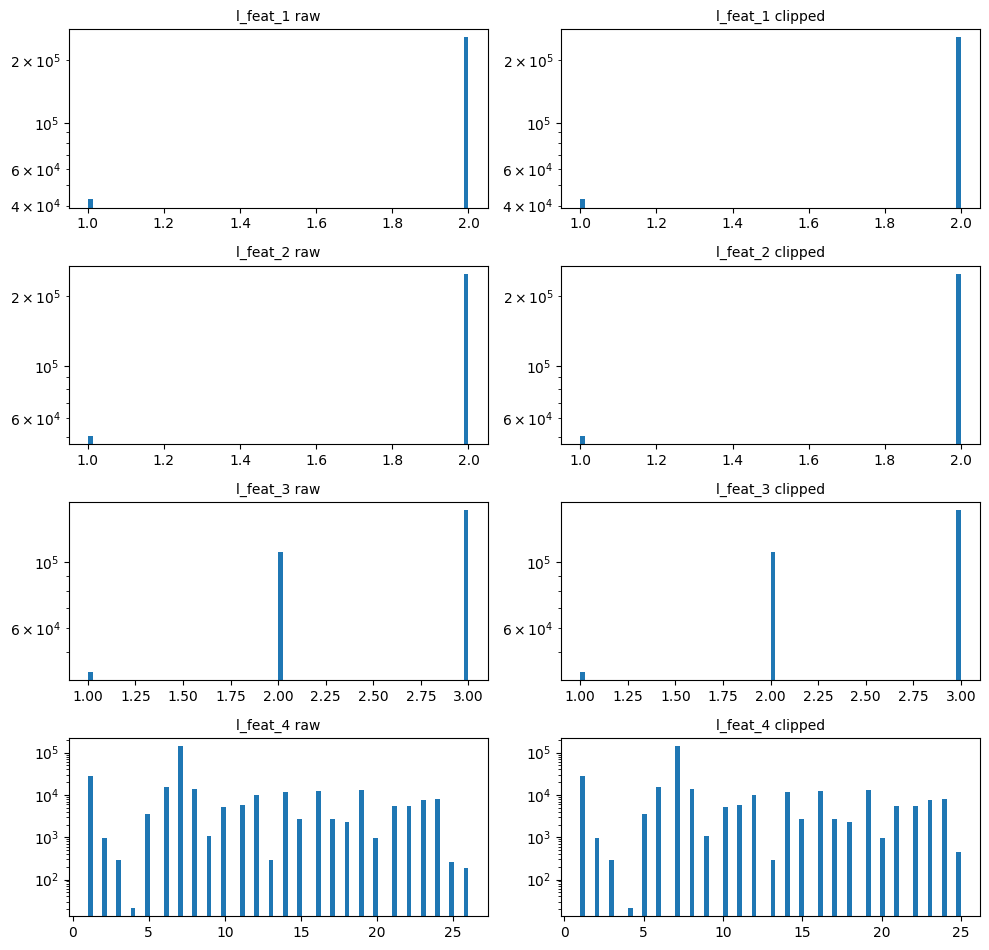

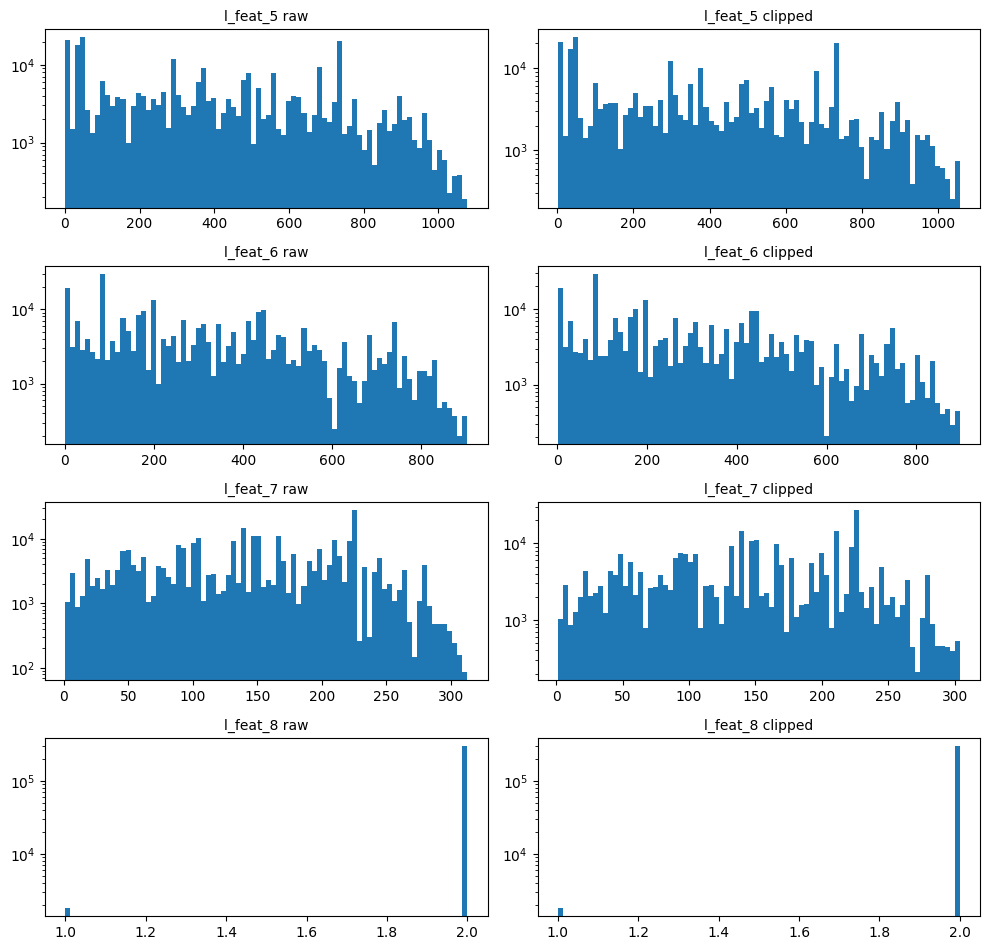

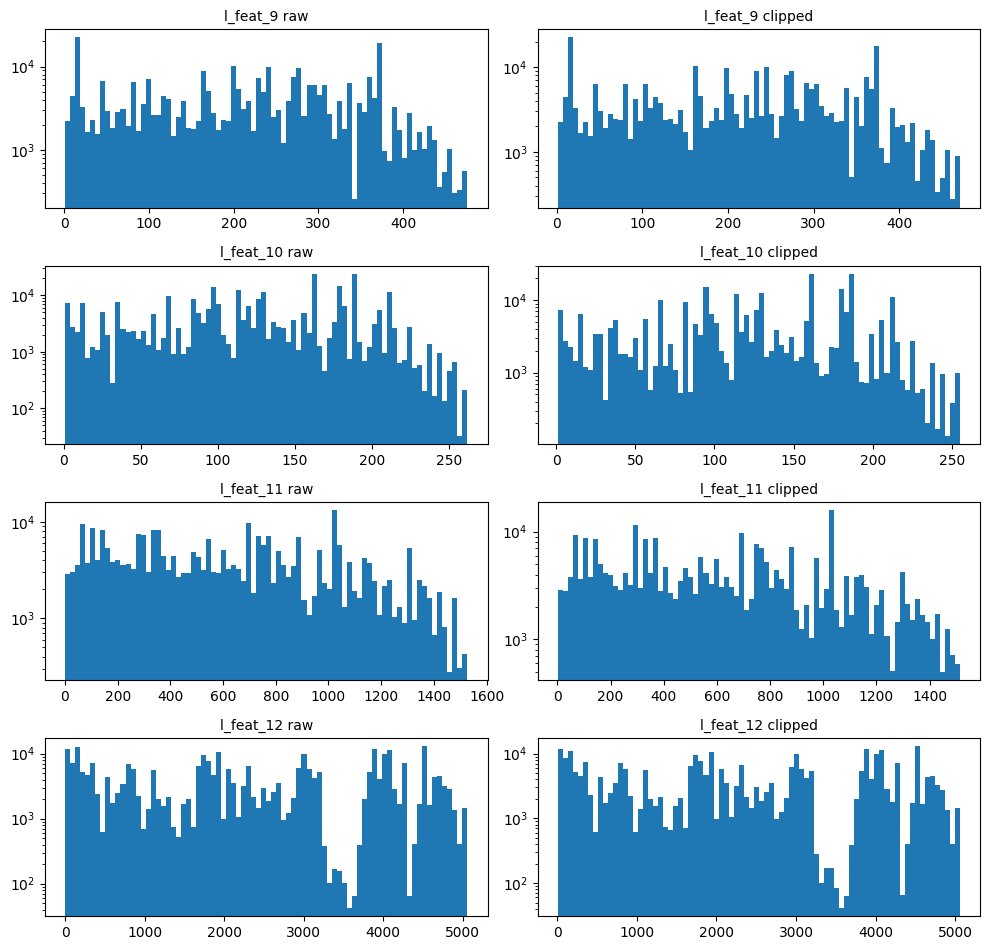

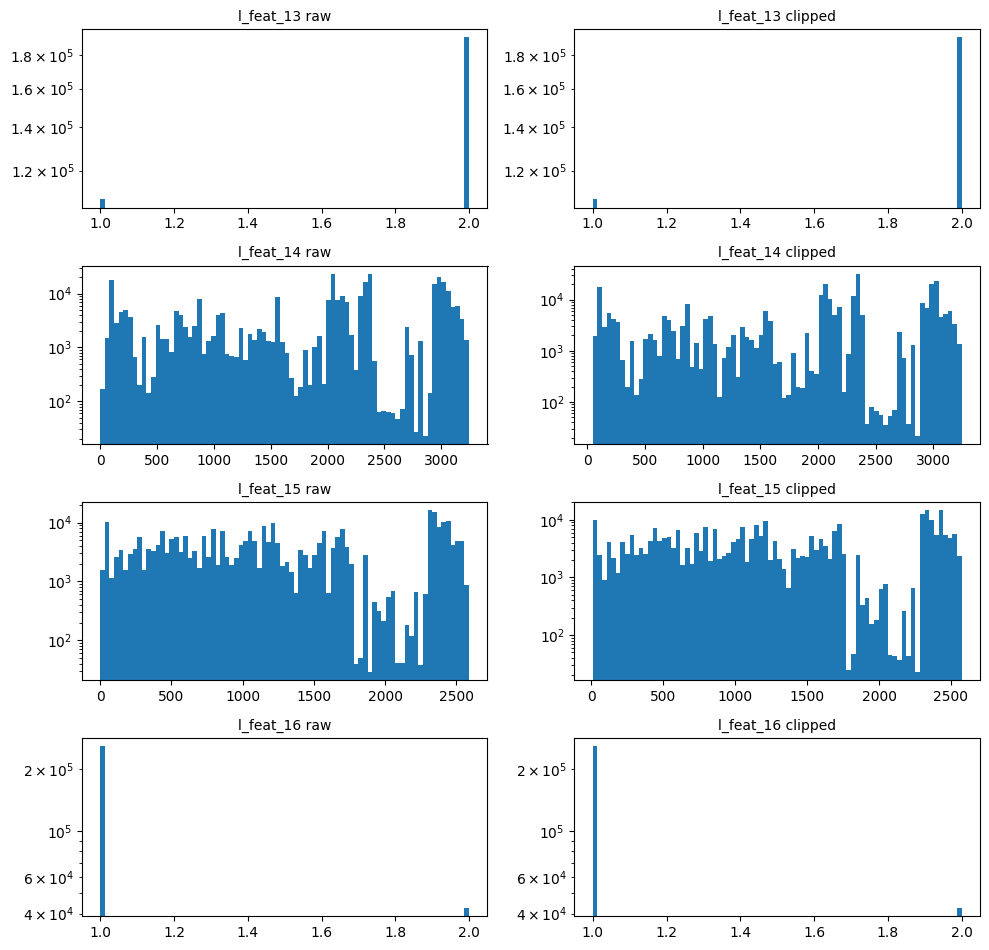

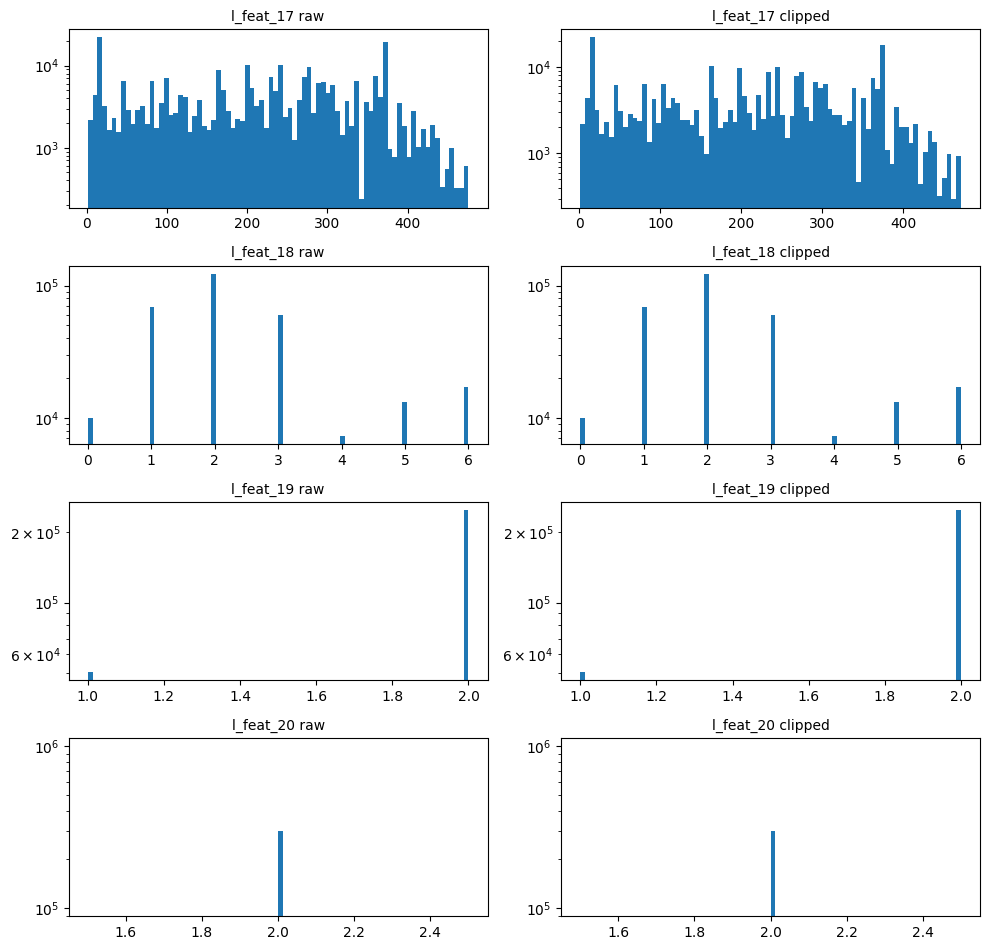

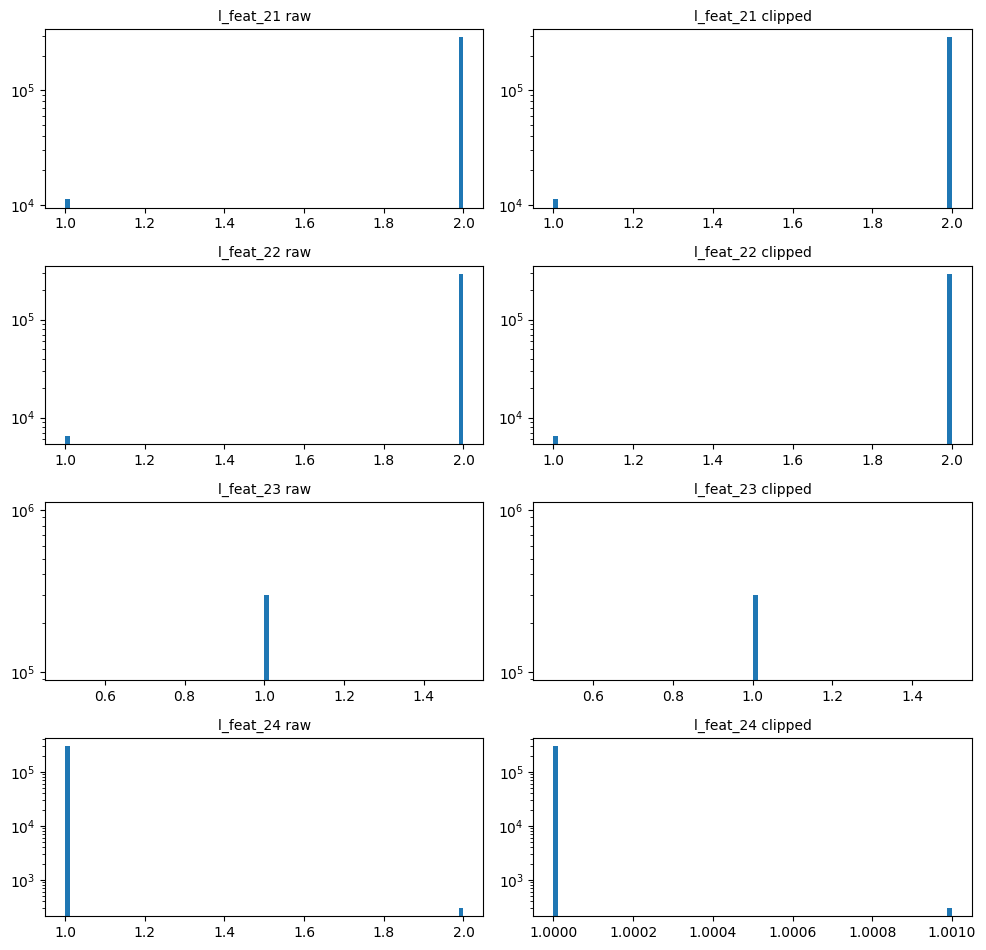

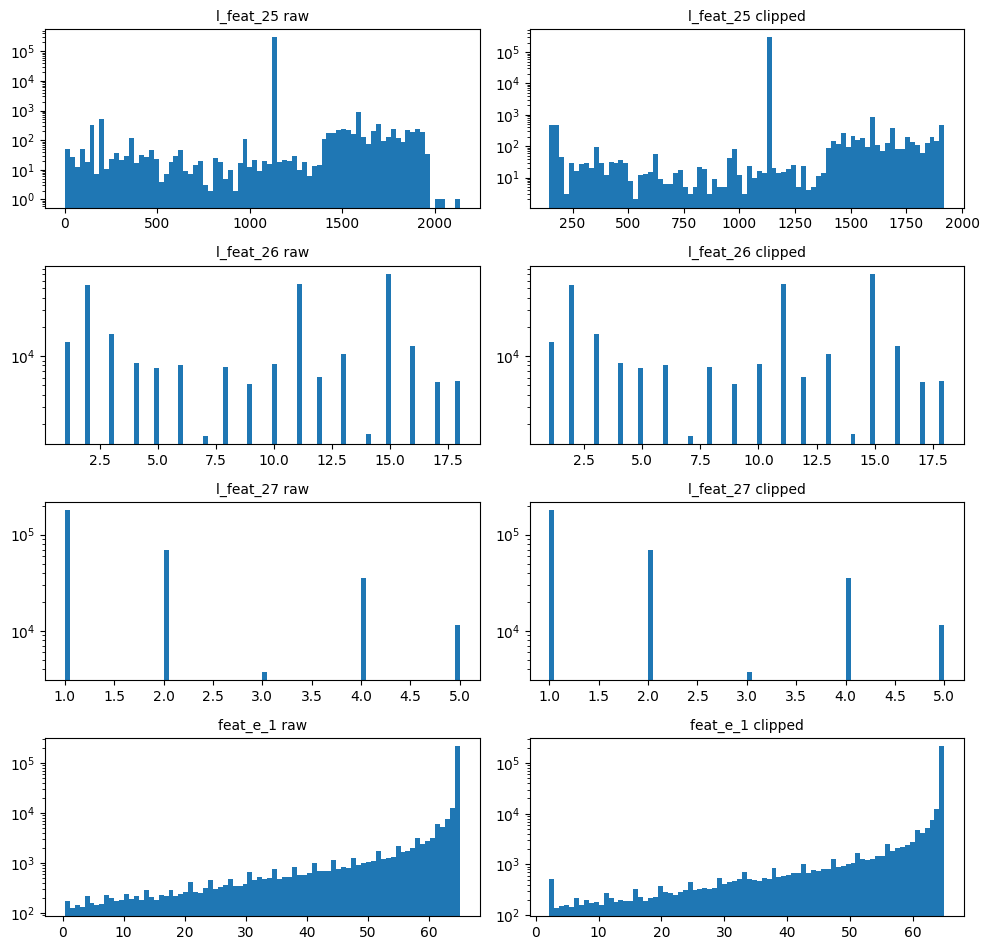

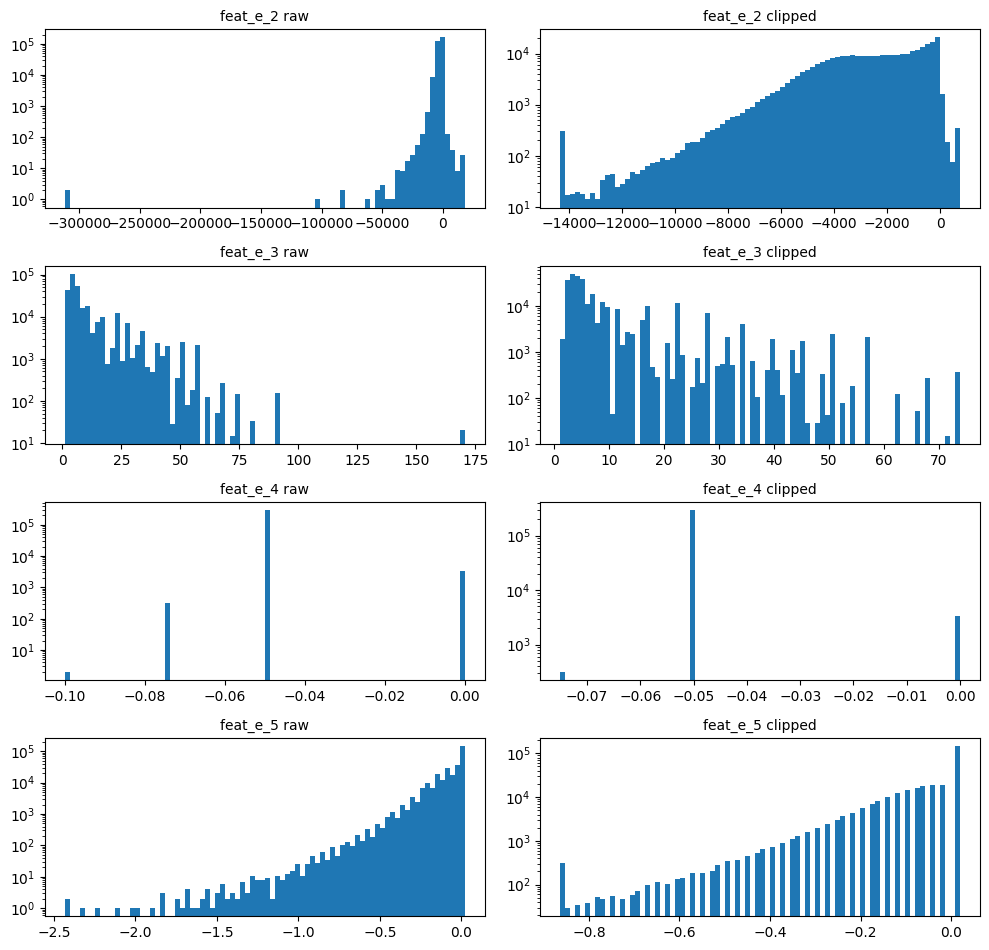

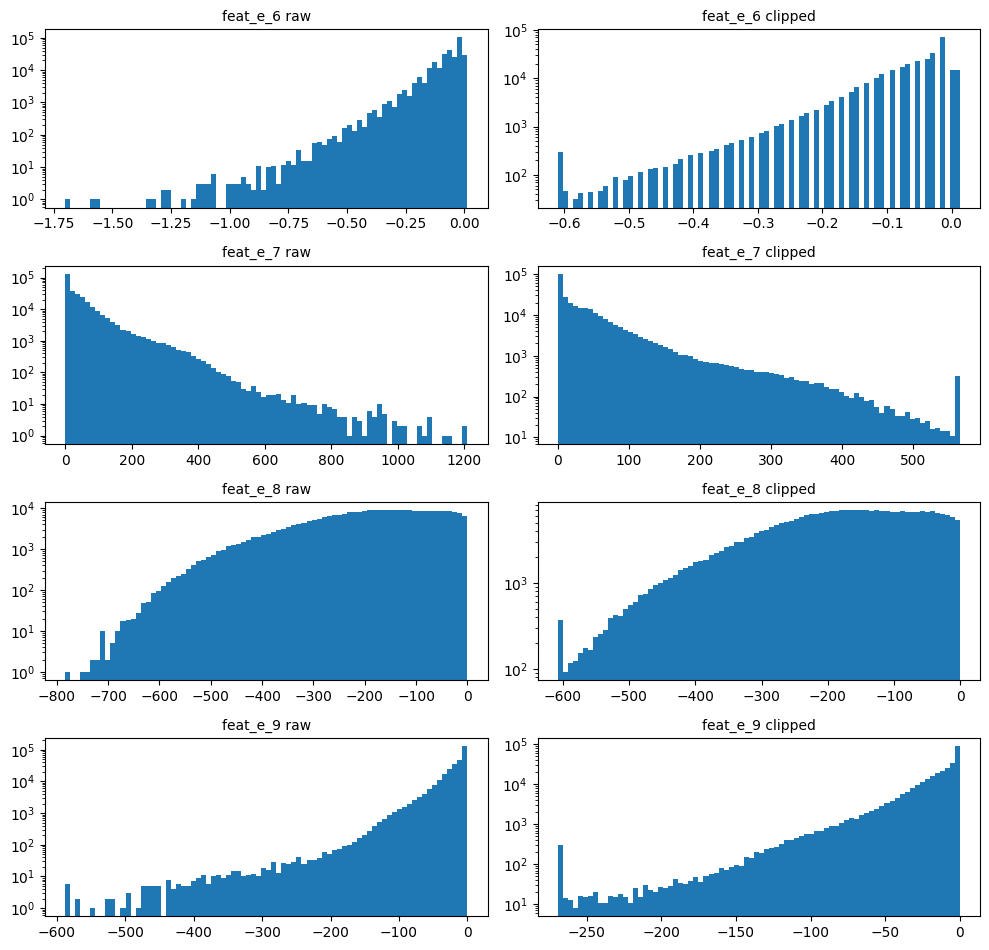

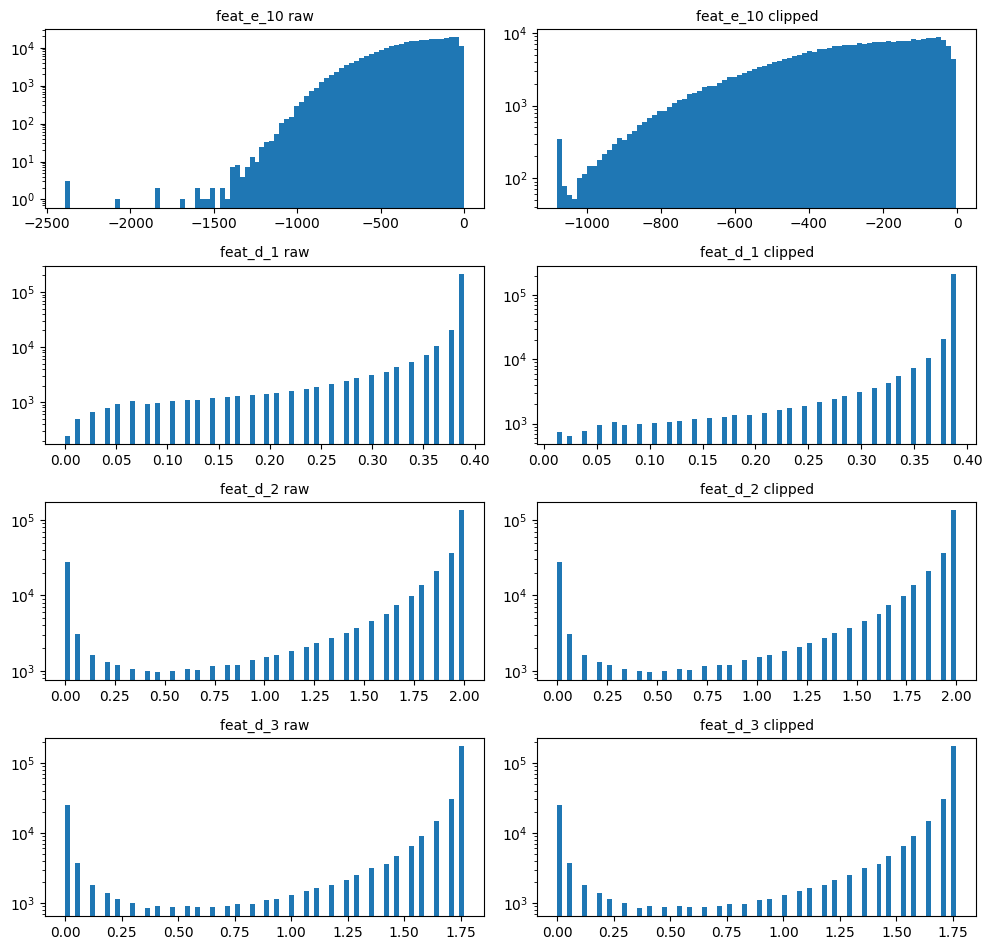

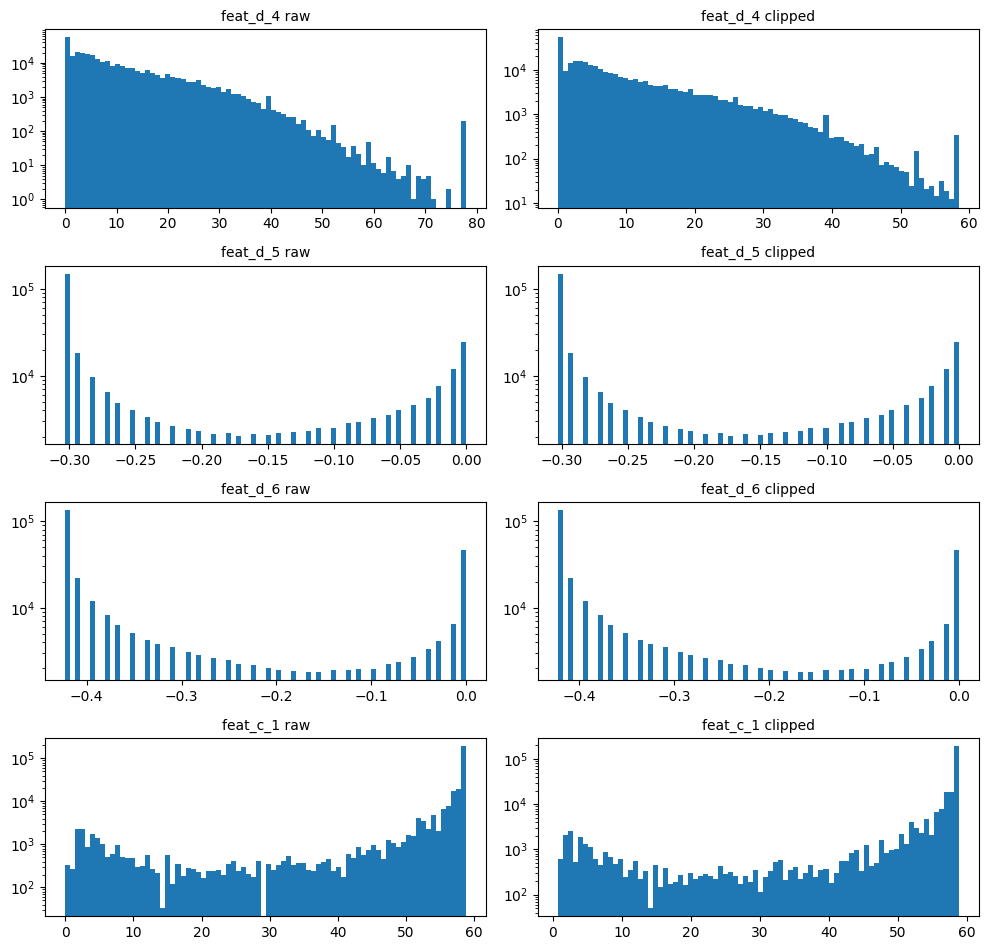

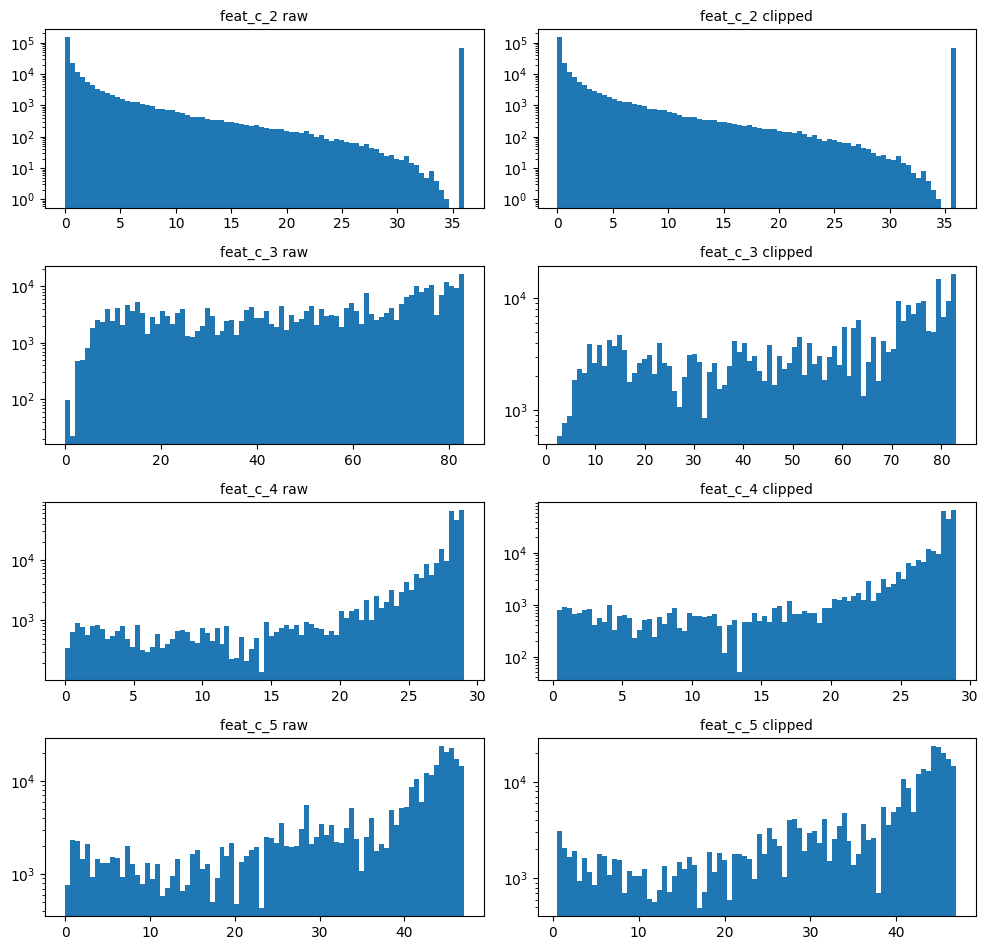

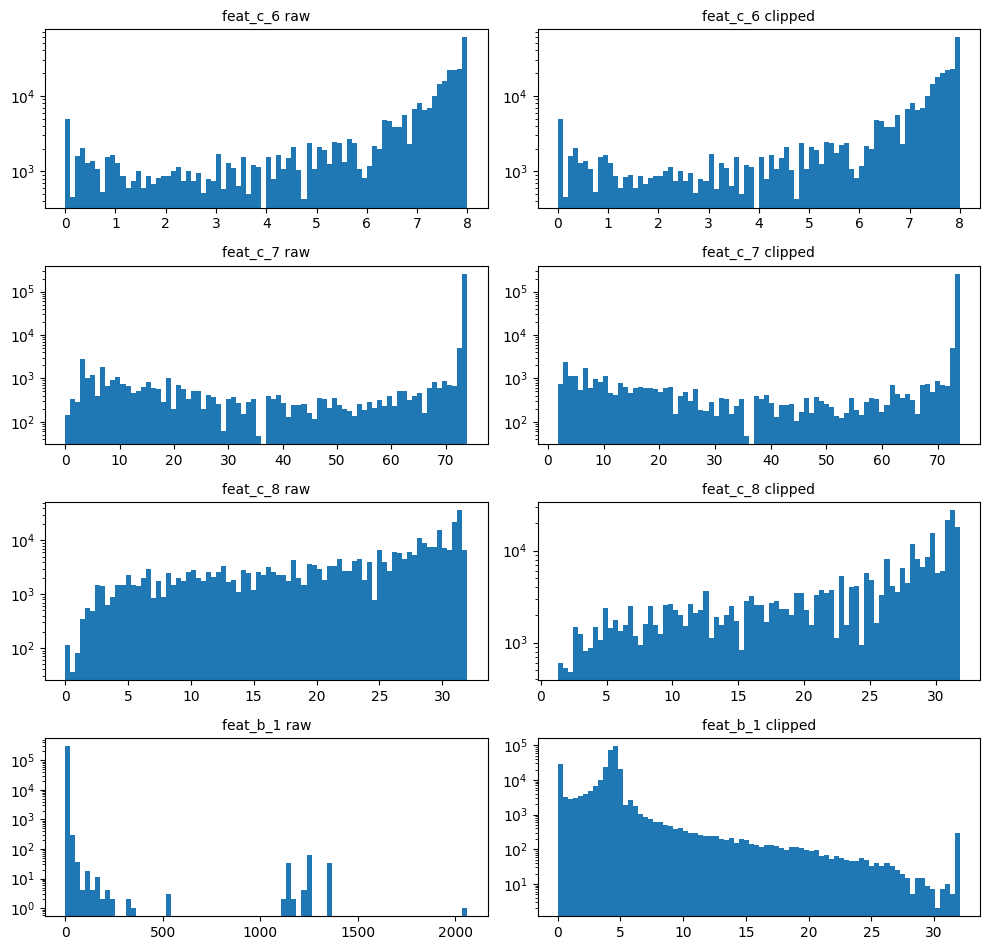

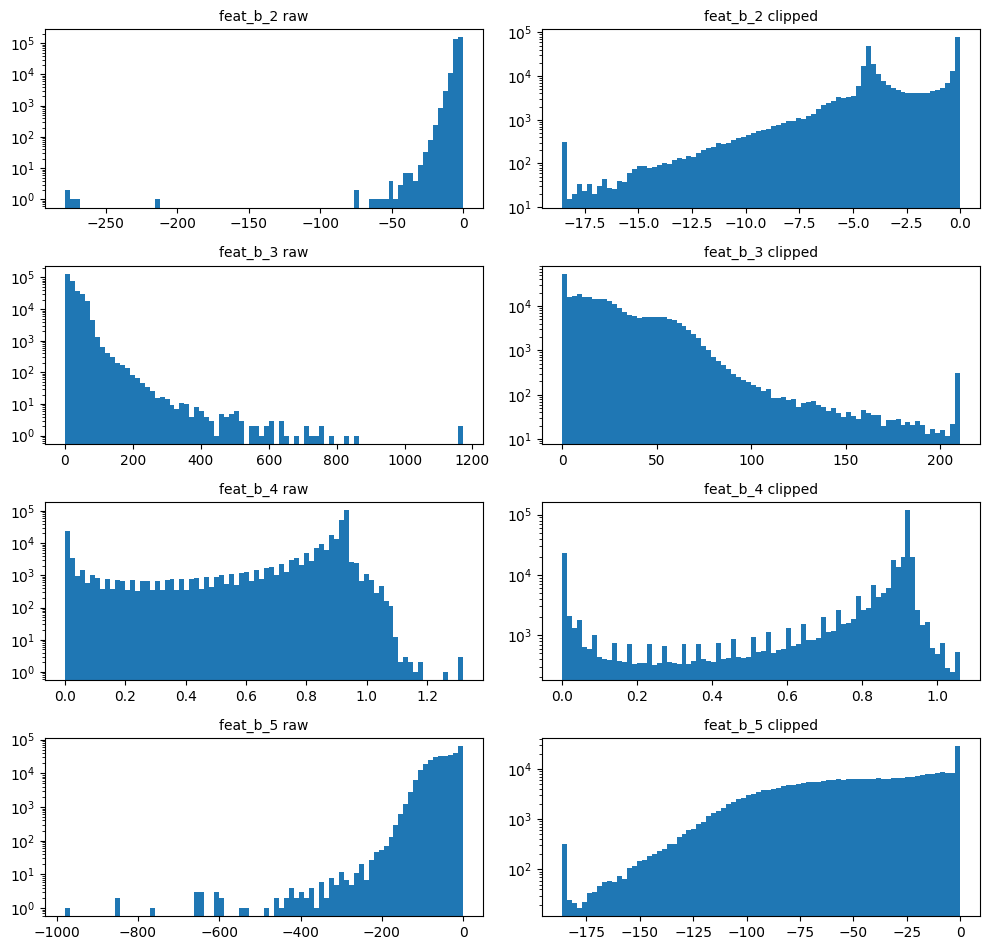

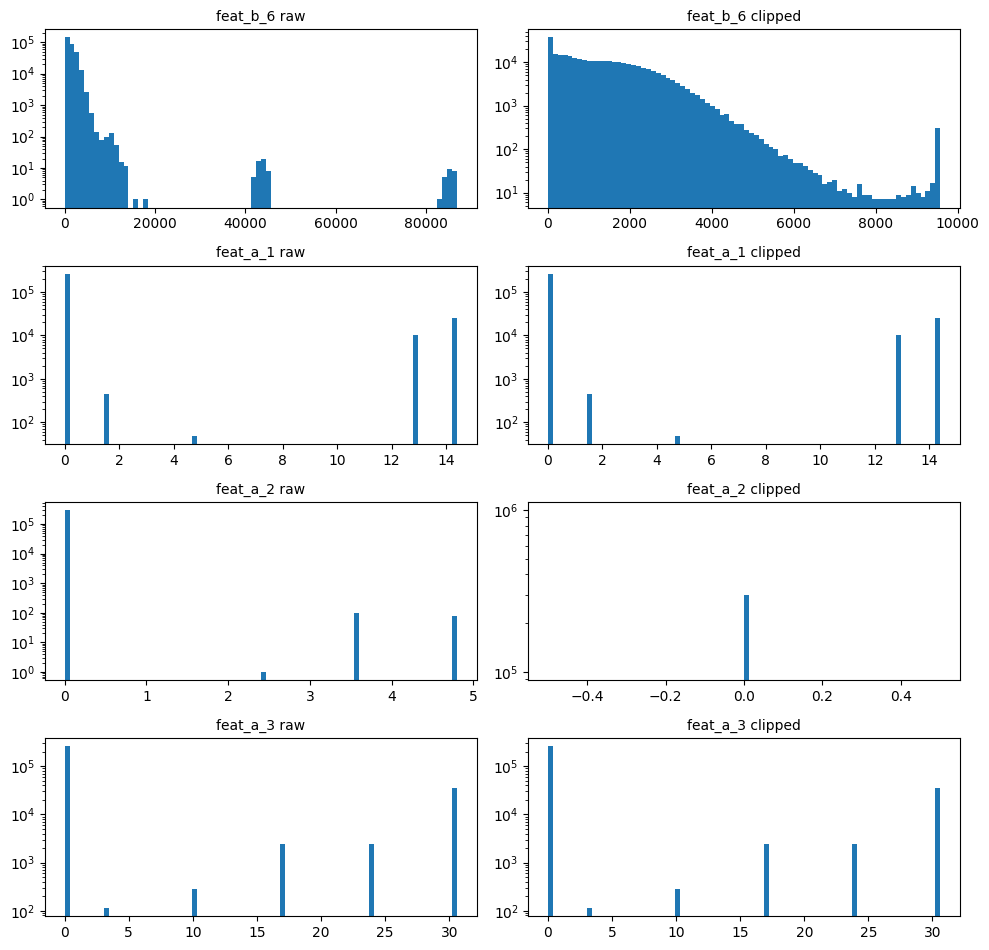

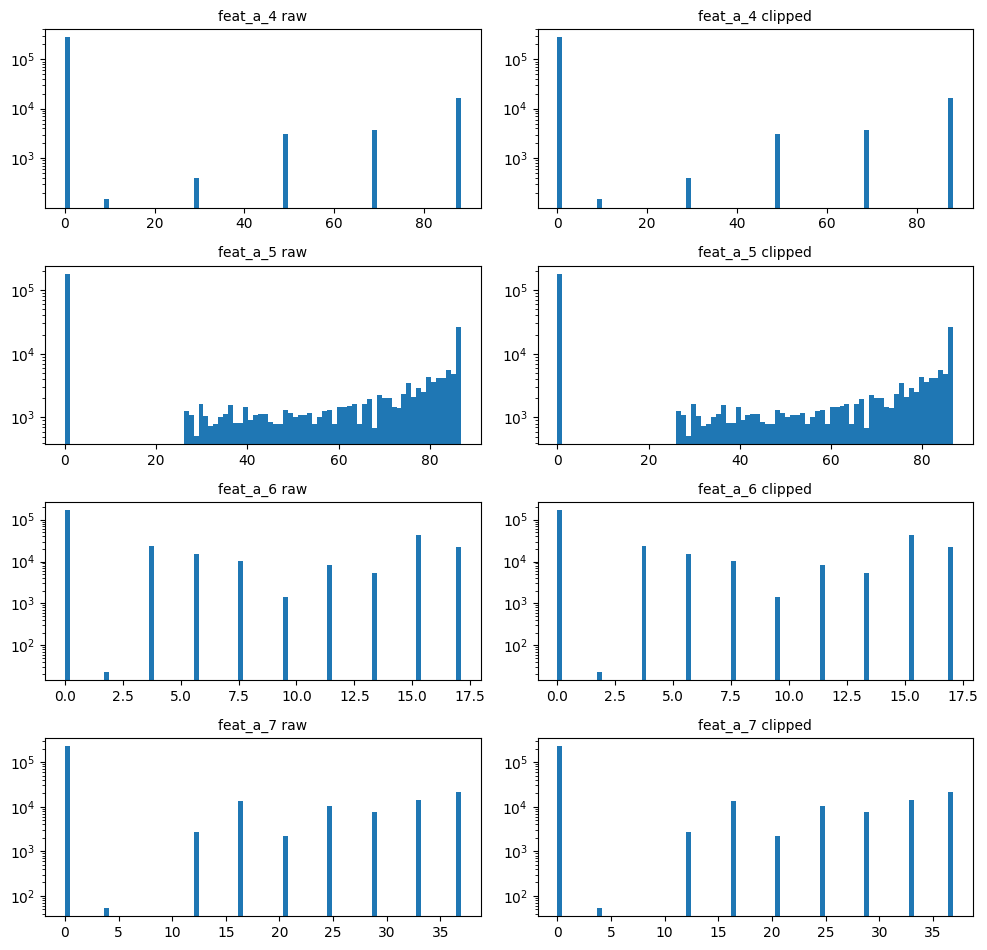

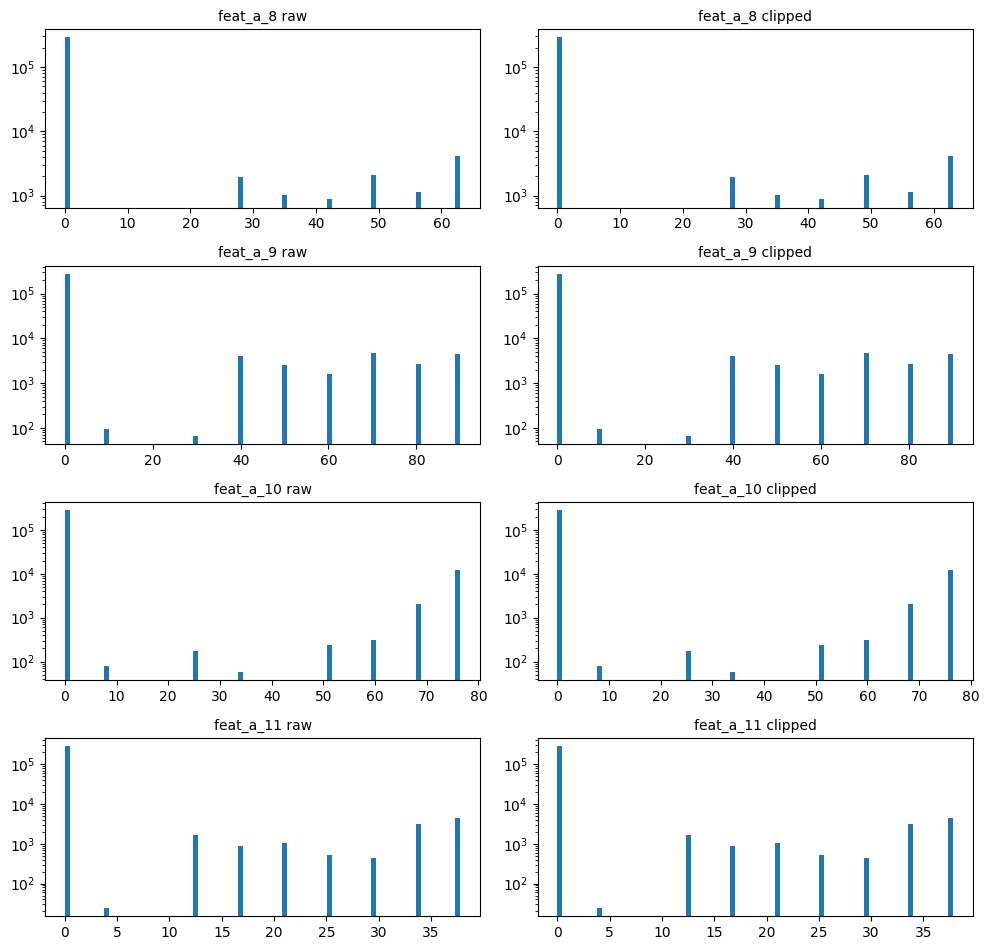

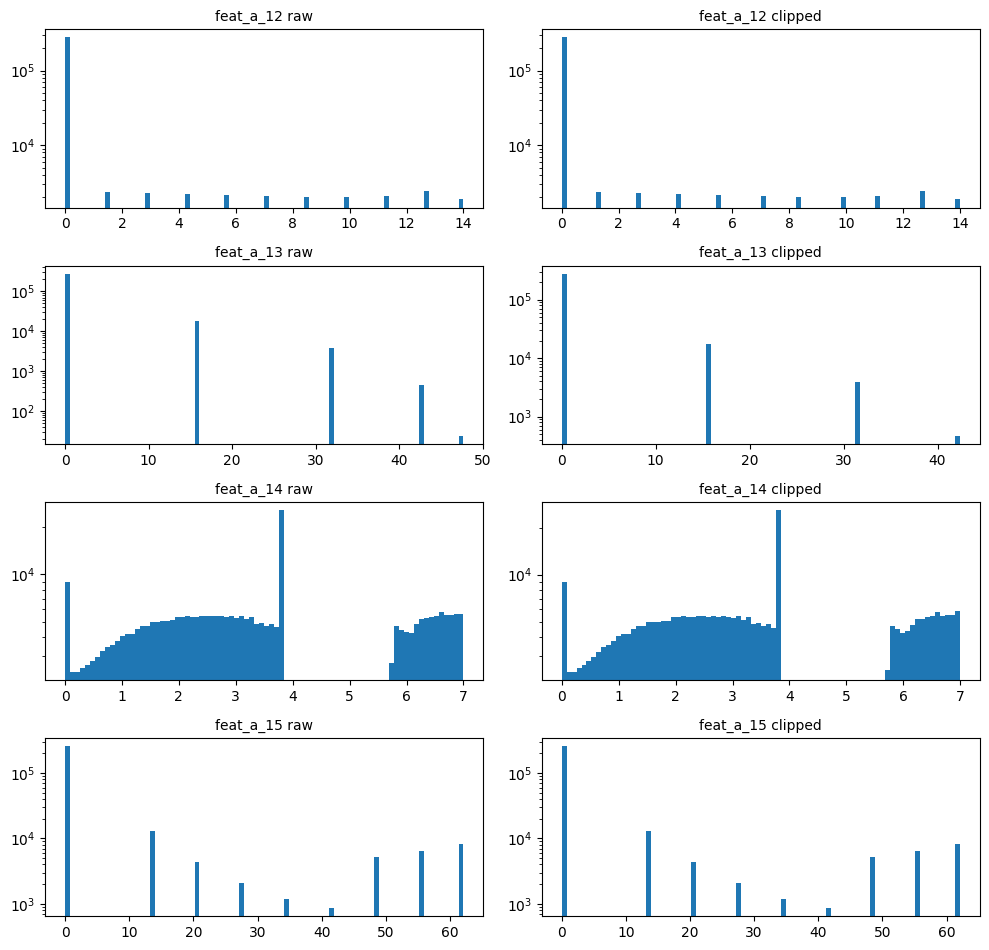

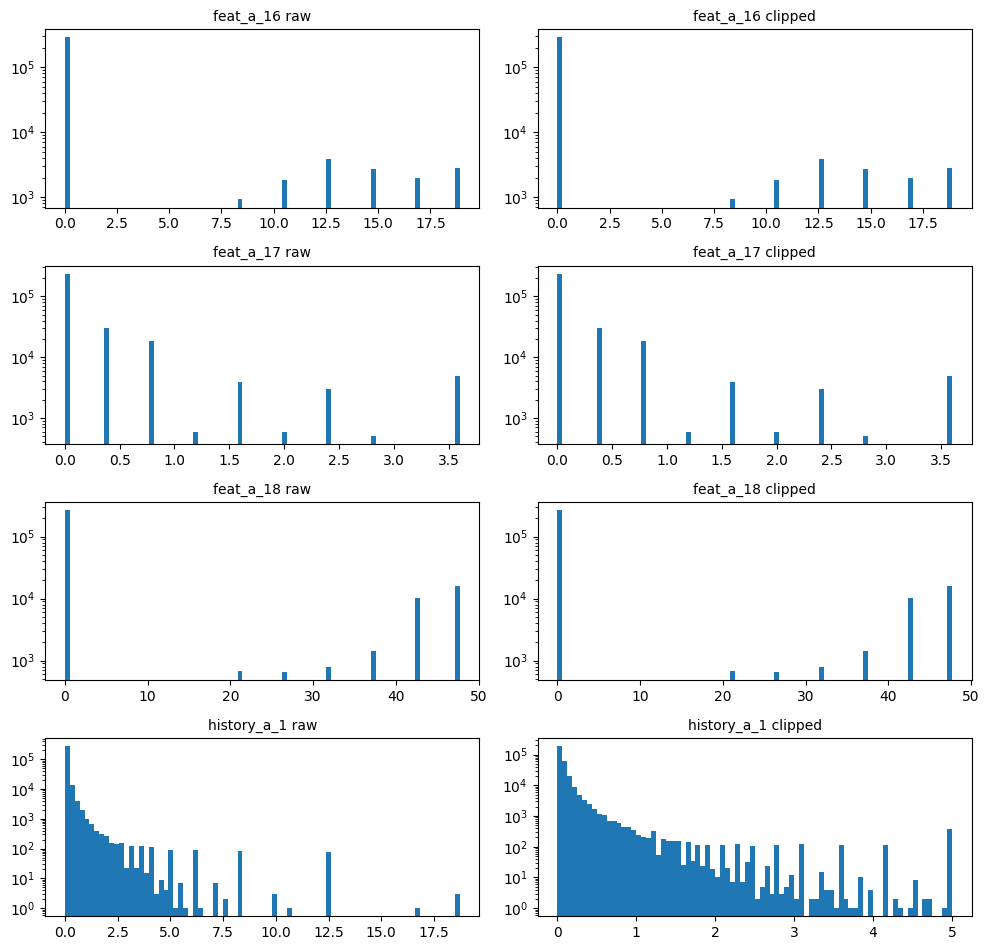

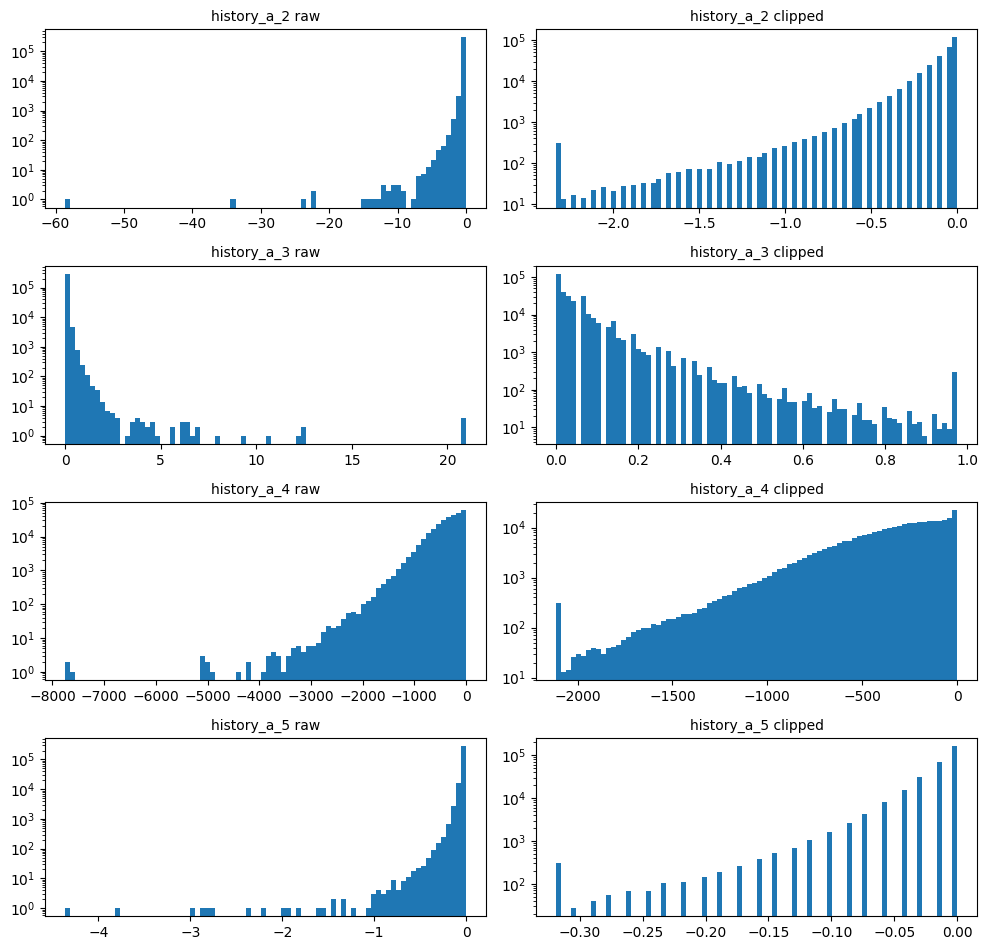

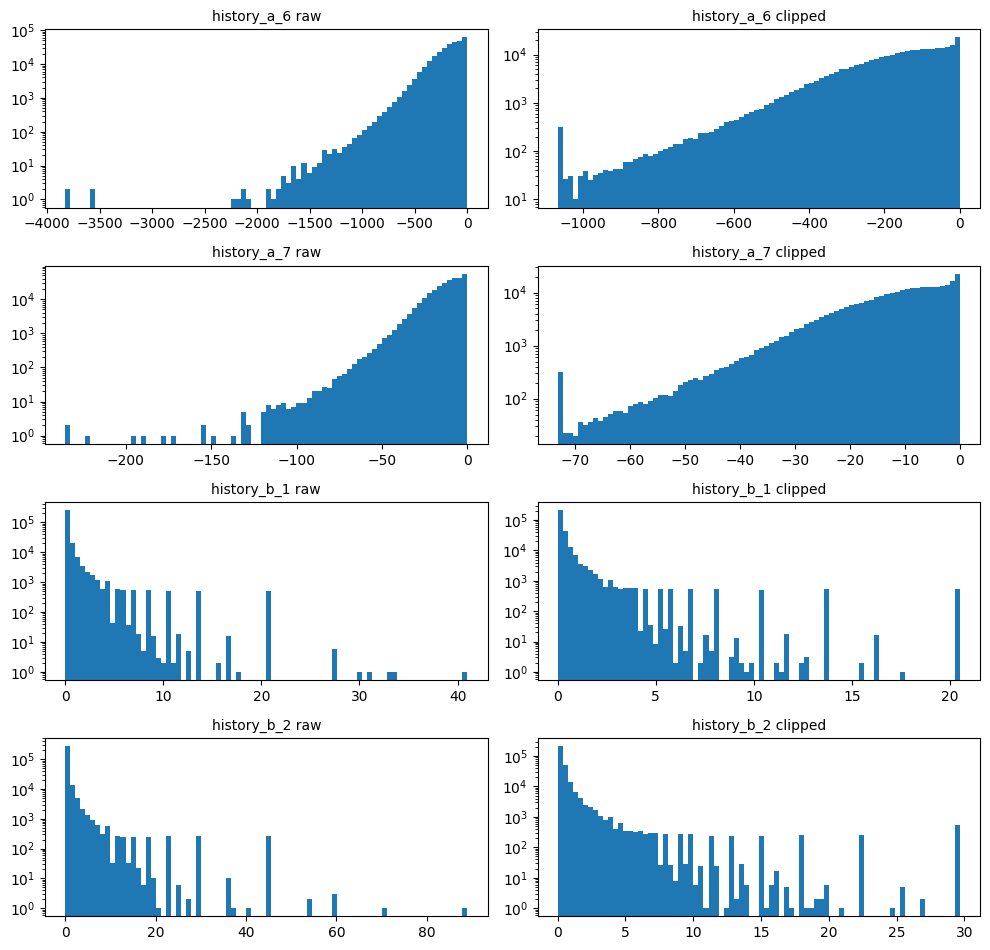

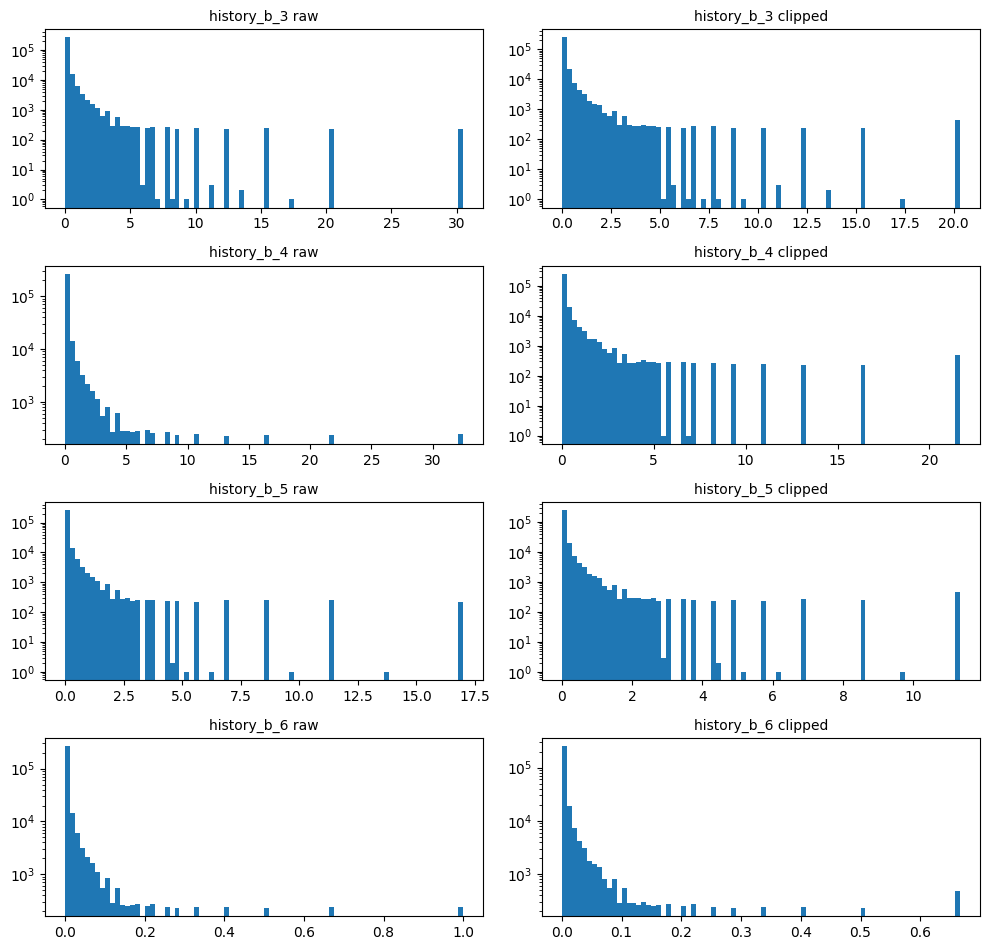

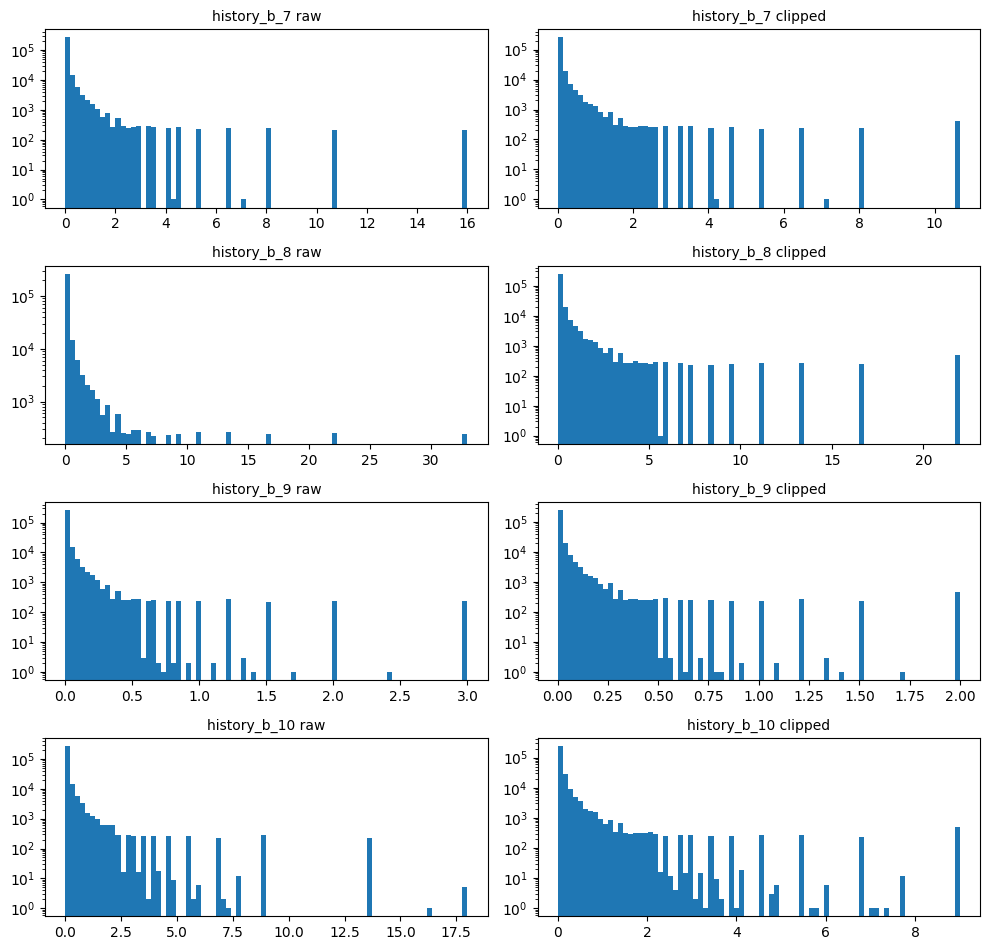

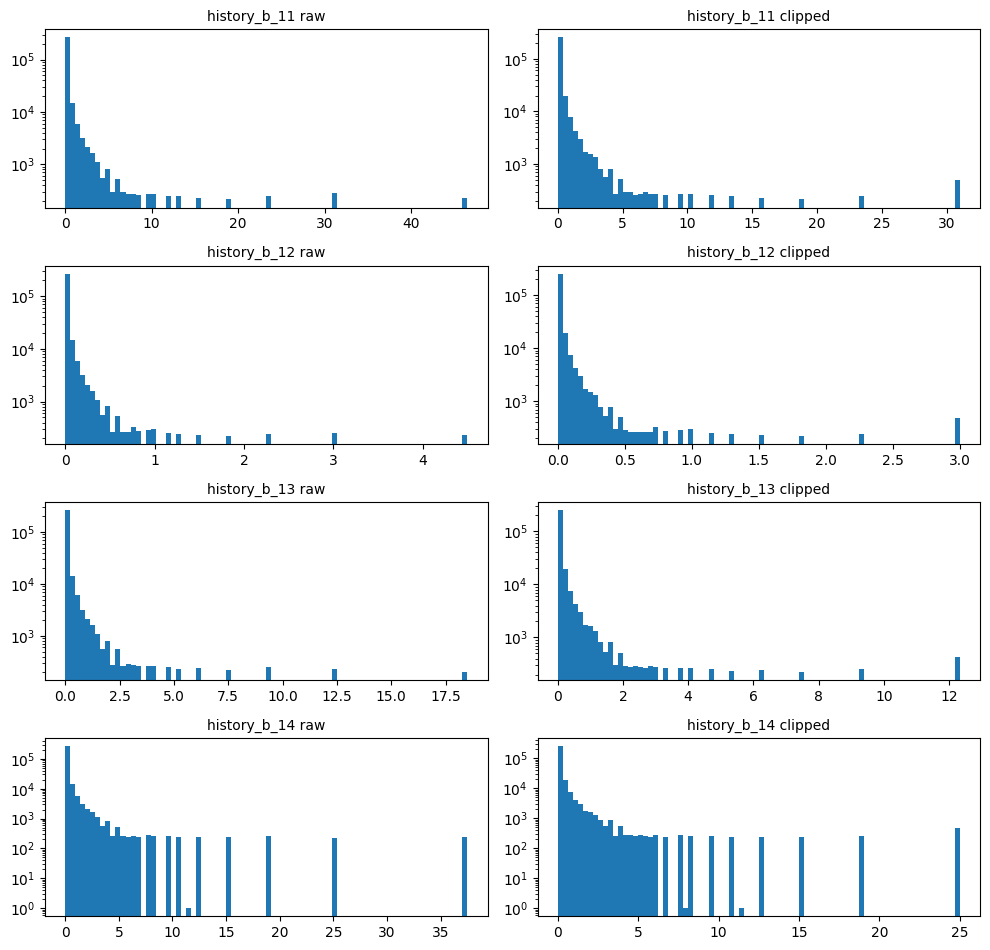

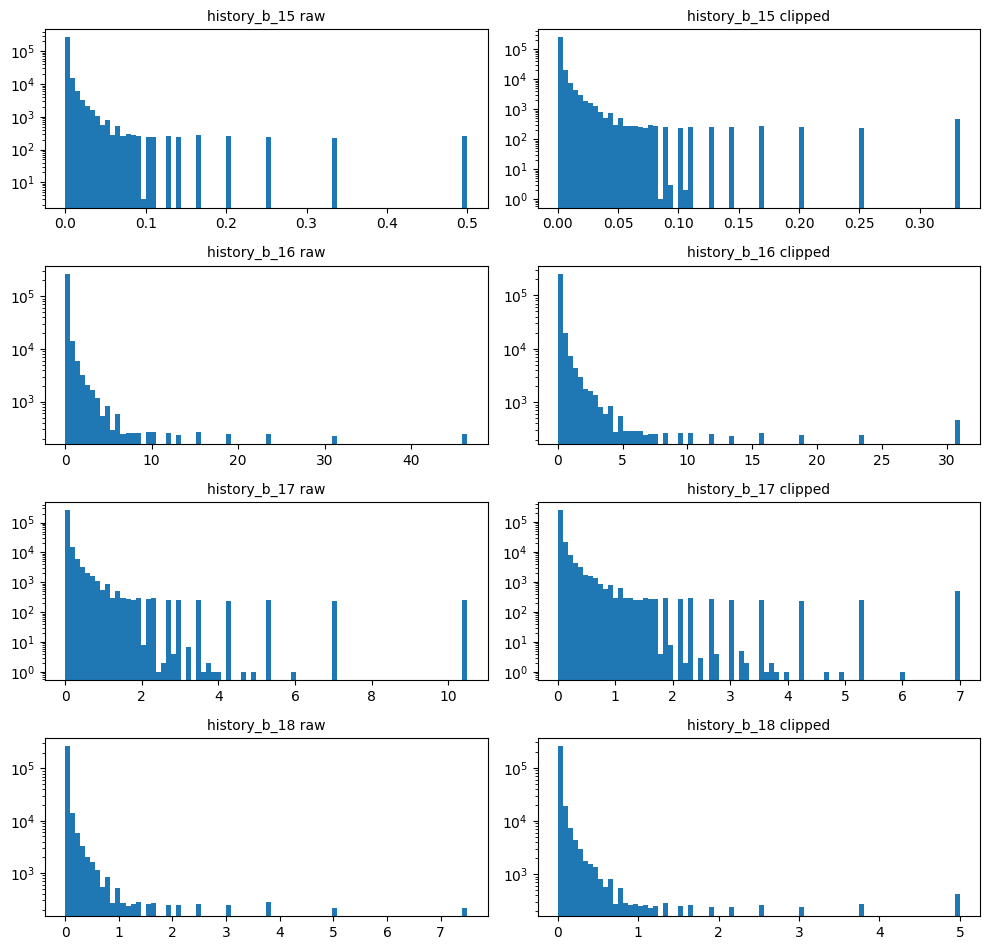

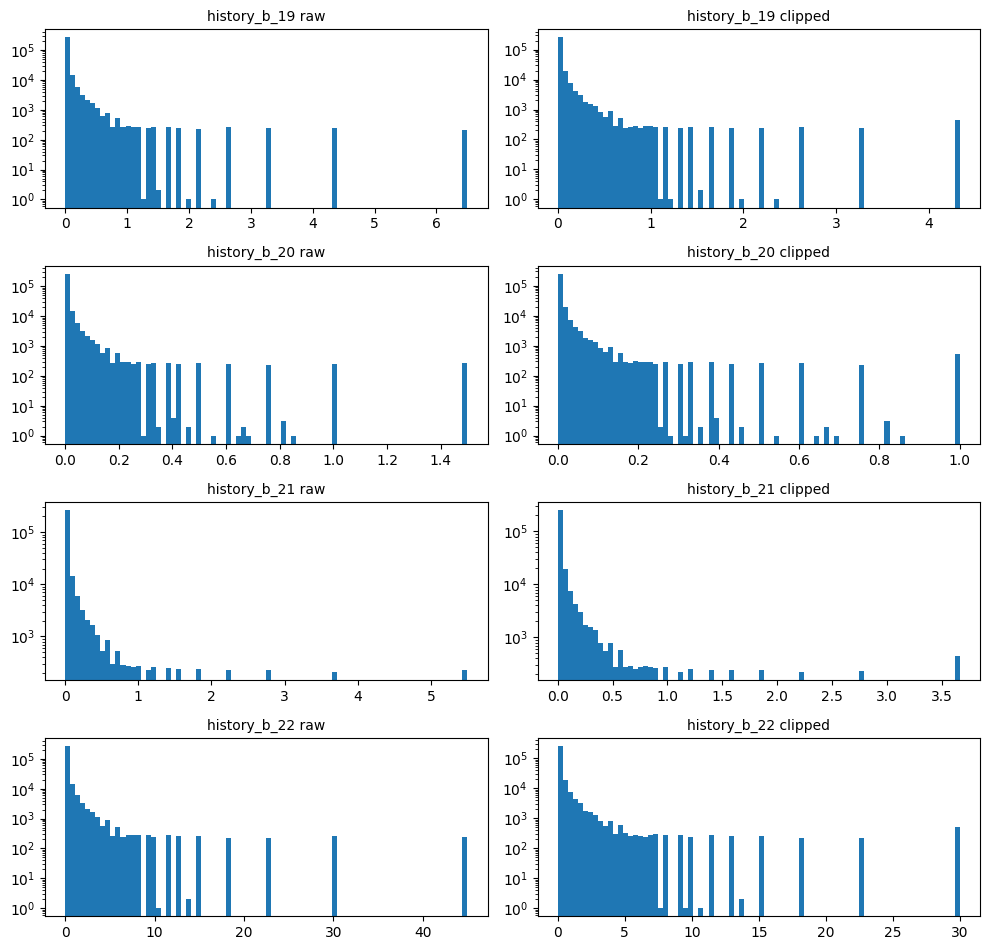

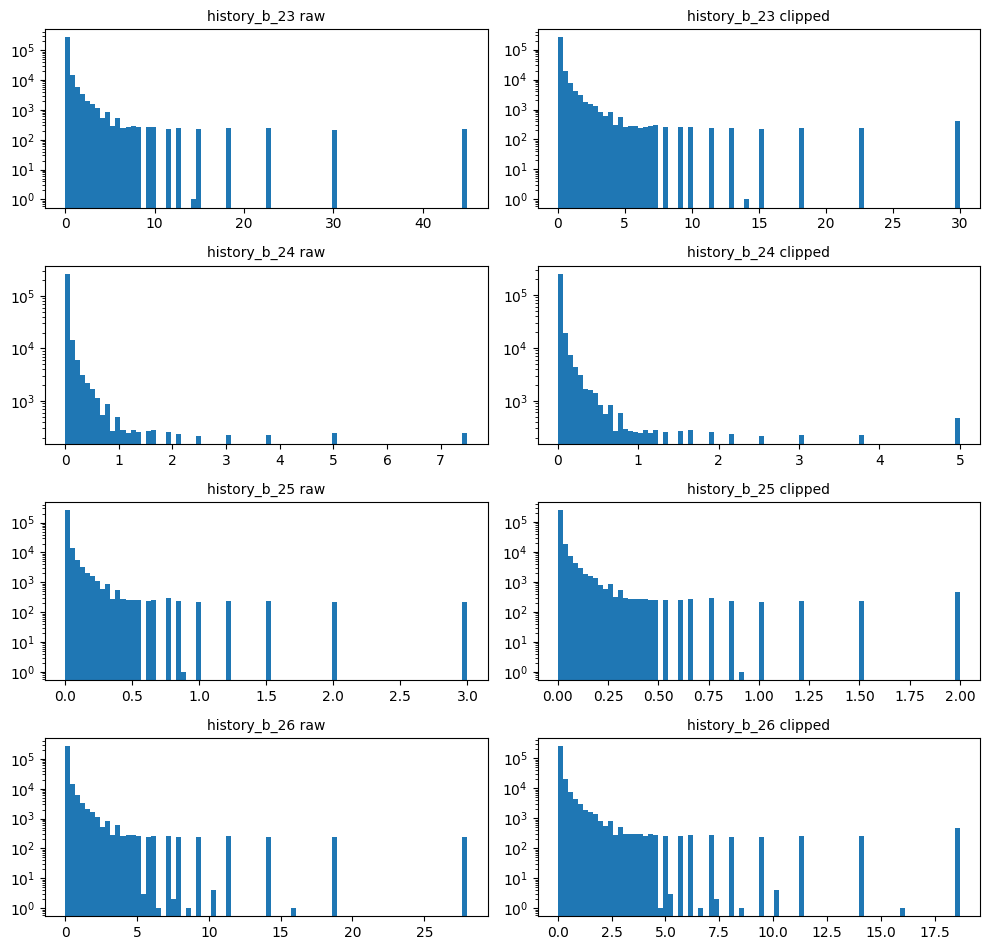

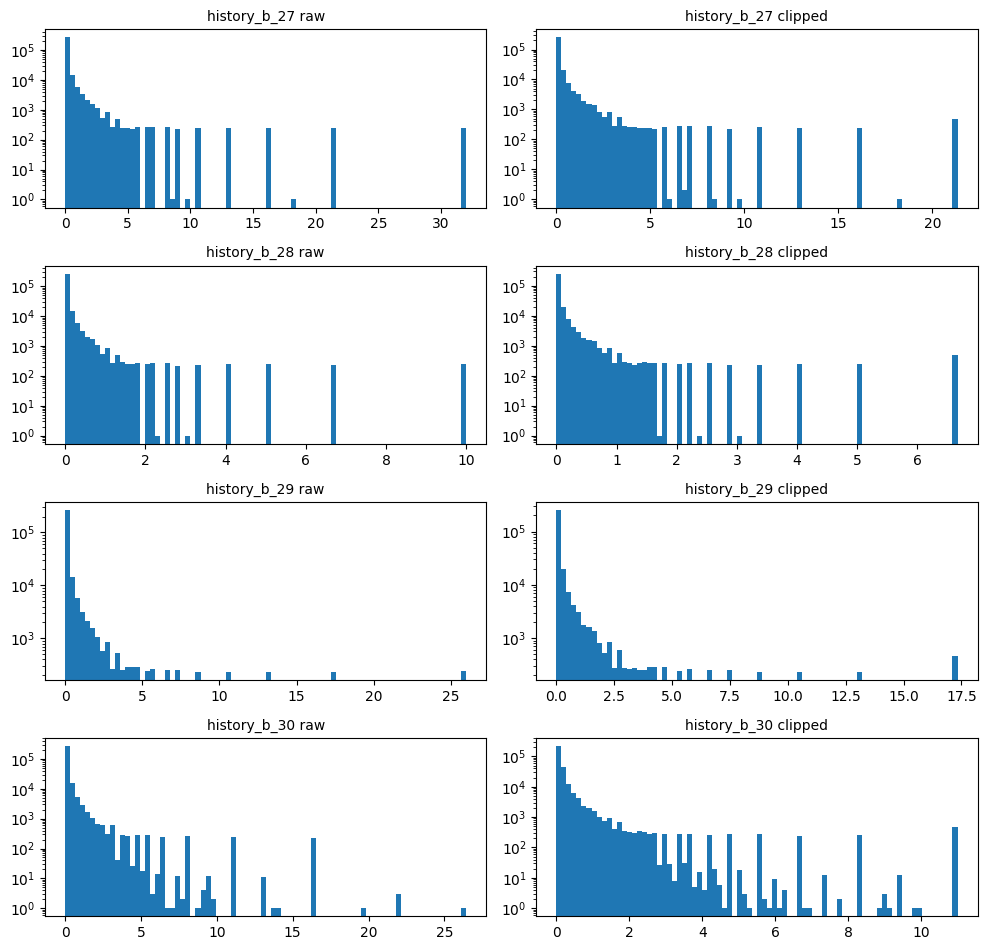

,col,n,uniq,zero_pct,lo,hi,tail_lo,tail_hi,skew,kurt,min_5,max_5
0,l_feat_1,300000,2,0.00,1.0,2.000000,0,0,-2.043,2.175,"[1.0, 1.0, 1.0, 1.0, 1.0]","[2.0, 2.0, 2.0, 2.0, 2.0]"
1,l_feat_2,300000,2,0.00,1.0,2.000000,0,0,-1.772,1.141,"[1.0, 1.0, 1.0, 1.0, 1.0]","[2.0, 2.0, 2.0, 2.0, 2.0]"
2,l_feat_3,300000,3,0.00,1.0,3.000000,0,0,-0.646,-0.832,"[1.0, 1.0, 1.0, 1.0, 1.0]","[3.0, 3.0, 3.0, 3.0, 3.0]"
3,l_feat_4,300000,26,0.00,1.0,25.000000,0,192,0.967,0.162,"[1.0, 1.0, 1.0, 1.0, 1.0]","[26.0, 26.0, 26.0, 26.0, 26.0]"
4,l_feat_5,300000,1063,0.00,1.0,1058.000000,0,219,0.262,-1.111,"[1.0, 1.0, 1.0, 1.0, 1.0]","[1078.0, 1077.0, 1077.0, 1077.0, 1077.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
107,history_b_26,300000,8637,0.13,0.0,18.666664,0,249,13.781,244.456,"[0.0, 0.0, 0.0, 0.0, 0.0]","[28.0, 28.0, 28.0, 28.0, 28.0]"
108,history_b_27,300000,8437,0.12,0.0,21.333332,0,249,13.936,249.141,"[0.0, 0.0, 0.0, 0.0, 0.0]","[32.0, 32.0, 32.0, 32.0, 32.0]"
109,history_b_28,300000,8466,0.12,0.0,6.666666,0,244,13.991,251.772,"[0.0, 0.0, 0.0, 0.0, 0.0]","[10.0, 10.0, 10.0, 10.0, 10.0]"
110,history_b_29,300000,5888,0.13,0.0,17.333332,0,239,13.987,252.669,"[0.0, 0.0, 0.0, 0.0, 0.0]","[26.0, 26.0, 26.0, 26.0, 26.0]"


,col,n,uniq,zero_pct,lo,hi,tail_lo,tail_hi,skew,kurt,min_5,max_5
0,l_feat_1,300000,2,0.00,1.0,2.000000,0,0,-2.043,2.175,"[1.0, 1.0, 1.0, 1.0, 1.0]","[2.0, 2.0, 2.0, 2.0, 2.0]"
1,l_feat_2,300000,2,0.00,1.0,2.000000,0,0,-1.772,1.141,"[1.0, 1.0, 1.0, 1.0, 1.0]","[2.0, 2.0, 2.0, 2.0, 2.0]"
2,l_feat_3,300000,3,0.00,1.0,3.000000,0,0,-0.646,-0.832,"[1.0, 1.0, 1.0, 1.0, 1.0]","[3.0, 3.0, 3.0, 3.0, 3.0]"
3,l_feat_4,300000,26,0.00,1.0,25.000000,0,192,0.967,0.162,"[1.0, 1.0, 1.0, 1.0, 1.0]","[26.0, 26.0, 26.0, 26.0, 26.0]"
4,l_feat_5,300000,1063,0.00,1.0,1058.000000,0,219,0.262,-1.111,"[1.0, 1.0, 1.0, 1.0, 1.0]","[1078.0, 1077.0, 1077.0, 1077.0, 1077.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
107,history_b_26,300000,8637,0.13,0.0,18.666664,0,249,13.781,244.456,"[0.0, 0.0, 0.0, 0.0, 0.0]","[28.0, 28.0, 28.0, 28.0, 28.0]"
108,history_b_27,300000,8437,0.12,0.0,21.333332,0,249,13.936,249.141,"[0.0, 0.0, 0.0, 0.0, 0.0]","[32.0, 32.0, 32.0, 32.0, 32.0]"
109,history_b_28,300000,8466,0.12,0.0,6.666666,0,244,13.991,251.772,"[0.0, 0.0, 0.0, 0.0, 0.0]","[10.0, 10.0, 10.0, 10.0, 10.0]"
110,history_b_29,300000,5888,0.13,0.0,17.333332,0,239,13.987,252.669,"[0.0, 0.0, 0.0, 0.0, 0.0]","[26.0, 26.0, 26.0, 26.0, 26.0]"


In [11]:
plot_hist_scan(train_data)

### inventory_id

In [ ]:
# inv_id별 노출 수, 클릭 수, 클릭률, lift 확인
KEY = 'inventory_id'
Y = 'clicked'

global_ctr = train_data[Y].mean()

table = (
    train_data.groupby(KEY)[Y]
    .agg(n='size', pos='sum')
    .reset_index()
)

table['rate'] = table['pos'] / table['n']
table['lift'] = table['rate'] / global_ctr

print(f'global ctr: {global_ctr:.6f}')

# 노출 수가 많은 inv_id 확인
display(
    table.sort_values('n', ascending=False)
    .head(5)
)

# 노출 수가 충분한 inv_id 중 lift가 높은 항목 확인
MIN_N = 100000

display(
    table[table['n'] >= MIN_N]
    .sort_values('lift', ascending=False)
    .head(5)
)

global ctr: 0.019075


,inventory_id,n,pos,rate,lift
2,2,2630473,23113,0.008787,0.460643
6,36,1518438,22973,0.015129,0.793164
7,37,1396465,41778,0.029917,1.568411
4,29,1015710,21594,0.021260,1.114566
10,42,1013762,22460,0.022155,1.161491


,inventory_id,n,pos,rate,lift
14,88,668809,25639,0.038335,2.009746
9,41,236609,8557,0.036165,1.895975
7,37,1396465,41778,0.029917,1.568411
15,91,101032,2752,0.027239,1.428012
5,31,434347,9971,0.022956,1.203495


In [ ]:
# train/test 간 inv_id 차이 확인
KEY = 'inventory_id'

train_ids = set(train_data[KEY].astype(str))
test_ids = set(test_data[KEY].astype(str))

only_train = train_ids - test_ids
only_test = test_ids - train_ids
both = train_ids & test_ids

print(f'train unique inv_id: {len(train_ids):,}')
print(f'test unique inv_id: {len(test_ids):,}')
print(f'both: {len(both):,}')
print(f'only train: {len(only_train):,}')
print(f'only test: {len(only_test):,}')

train unique inv_id: 18
test unique inv_id: 18
both: 18
only train: 0
only test: 0


### seq

== seq_len describe ==
count    300000.000000
mean        530.883960
std         434.450902
min           1.000000
50%         439.000000
75%         779.000000
90%        1122.000000
95%        1345.000000
99%        1851.000000
max        6781.000000
Name: seq_len, dtype: float64


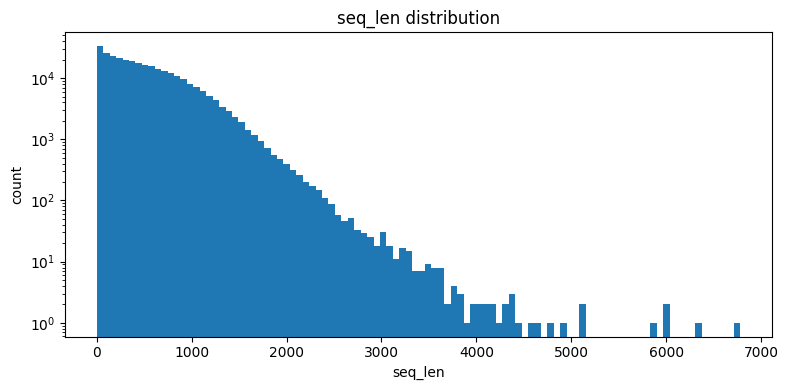


== seq_last Top5 ==


,seq_last,count,share,cum_share
0,35,143250,0.4775,0.4775
1,479,131917,0.439723,0.917223
2,519,3860,0.012867,0.93009
3,101,2569,0.008563,0.938653
4,77,2568,0.00856,0.947213



== last2 Top5 ==


,last2,count,share,cum_share
0,"479,35",139833,0.46611,0.46611
1,"35,479",82969,0.276563,0.742673
2,"77,479",5802,0.01934,0.762013
3,"479,479",4072,0.013573,0.775587
4,"57,479",3988,0.013293,0.78888



== last3 Top5 ==


...

,seq_last,n,pos,ctr,lift,share
1,35,143250,2796,0.019518,1.028905,0.477500
2,479,131917,2392,0.018133,0.955857,0.439723
3,519,3860,82,0.021244,1.119848,0.012867
0,101,2569,42,0.016349,0.861823,0.008563
4,77,2568,35,0.013629,0.718465,0.008560



== last2 Top5 CTR ==
global ctr: 0.018970


,last2,n,pos,ctr,lift,share
1,"479,35",139833,2744,0.019623,1.034444,0.466110
0,"35,479",82969,1429,0.017223,0.907923,0.276563
4,"77,479",5802,75,0.012927,0.681422,0.019340
2,"479,479",4072,79,0.019401,1.022709,0.013573
3,"57,479",3988,93,0.023320,1.229307,0.013293



== last3 Top5 CTR ==
global ctr: 0.018970


,last3,n,pos,ctr,lift,share
4,"77,479,35",28117,470,0.016716,0.881174,0.093723
2,"74,479,35",23600,417,0.017669,0.931444,0.078667
3,"77,35,479",20270,289,0.014258,0.751583,0.067567
1,"74,35,479",19771,333,0.016843,0.887868,0.065903
0,"318,479,35",16261,285,0.017527,0.923911,0.054203


In [12]:
# seq 패턴 EDA용 샘플 생성
N = len(train_data)
S = min(300000, N)

rng = np.random.default_rng(42)
idx = rng.choice(N, size=S, replace=False)

df = train_data.iloc[idx].copy()

seq_s = df['seq'].astype('string').fillna('')
inv_s = df['inventory_id'].astype('string').fillna('')

# seq 기본 피처
df['seq_len'] = seq_s.str.count(',').add(1).astype('int16')
df['seq_last'] = seq_s.str.extract(r'([^,]+)$')[0]
df['last2'] = seq_s.str.extract(r'([^,]+,[^,]+)$')[0]
df['last3'] = seq_s.str.extract(r'([^,]+,[^,]+,[^,]+)$')[0]

df['is_last_eq_inv'] = df['seq_last'].eq(inv_s)

# seq 길이 분포 확인
print('== seq_len describe ==')
print(df['seq_len'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(df['seq_len'], bins=100)
plt.yscale('log')
plt.title('seq_len distribution')
plt.xlabel('seq_len')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# 상위 seq 패턴이 전체에서 차지하는 비율 확인
TOPK = 5

for col in ['seq_last', 'last2', 'last3']:
    vc = df[col].value_counts(dropna=True).head(TOPK)

    out = vc.reset_index()
    out.columns = [col, 'count']
    out['share'] = out['count'] / len(df)
    out['cum_share'] = out['share'].cumsum()

    print(f'\n== {col} Top{TOPK} ==')
    display(out)

# 상위 seq 패턴별 CTR / lift 확인
global_ctr = df['clicked'].mean()
TOPK = 5

for col in ['seq_last', 'last2', 'last3']:
    top_values = df[col].value_counts(dropna=True).head(TOPK).index

    table = (
        df[df[col].isin(top_values)]
        .groupby(col)['clicked']
        .agg(n='size', pos='sum')
        .reset_index()
    )

    table['ctr'] = table['pos'] / table['n']
    table['lift'] = table['ctr'] / global_ctr
    table['share'] = table['n'] / len(df)

    table = table.sort_values('n', ascending=False)

    print(f'\n== {col} Top{TOPK} CTR ==')
    print(f'global ctr: {global_ctr:.6f}')
    display(table)

In [ ]:
# seq 길이 상위 1%의 CTR 확인
seq_len = train_data['seq'].astype('string').str.count(',').add(1)

p99 = int(seq_len.quantile(0.99))
top1_mask = seq_len >= p99

overall_ctr = train_data['clicked'].mean()
top1_ctr = train_data.loc[top1_mask, 'clicked'].mean()

print(f'전체 CTR: {overall_ctr:.6f} (n={len(train_data):,})')
print(f'p99 seq_len: {p99}')
print(f'seq_len >= p99 CTR: {top1_ctr:.6f} (n={top1_mask.sum():,})')
print(f'lift: {top1_ctr / overall_ctr:.3f}')

전체 CTR: 0.019075 (n=10,704,179)
p99 seq_len: 1847
seq_len >= p99 CTR: 0.018592 (n=107,090)
lift: 0.975


In [ ]:
# seq 다양성 확인
N = len(train_data)
S = min(300000, N)

rng = np.random.default_rng(42)
idx = rng.choice(N, size=S, replace=False)

df = train_data.iloc[idx][['seq', 'clicked']].copy()

seq_s = df['seq'].astype('string')

df['seq_len'] = seq_s.str.count(',').add(1).astype('int32')

df['uniq_cnt'] = seq_s.map(
    lambda x: len(set(x.split(','))) if pd.notna(x) else np.nan
).astype('float32')

df['diversity_ratio'] = df['uniq_cnt'] / df['seq_len']

print('== diversity_ratio describe ==')
print(df['diversity_ratio'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

== diversity_ratio describe ==
count    300000.000000
mean          0.178893
std           0.161389
min           0.004456
10%           0.066456
25%           0.085992
50%           0.125541
75%           0.205575
90%           0.338583
95%           0.487179
99%           1.000000
max           1.000000
Name: diversity_ratio, dtype: float64


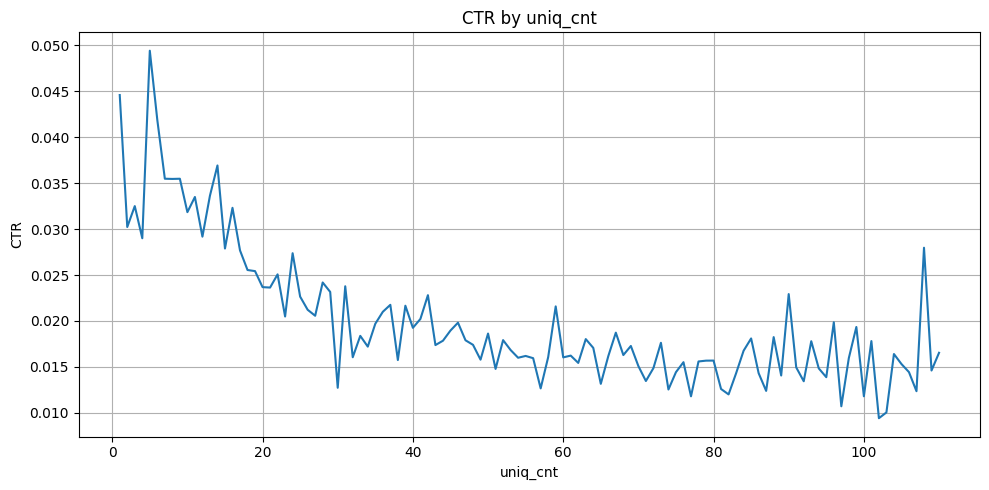

,uniq_cnt,ctr,n
0,1.0,0.044602,1973
1,2.0,0.030227,397
2,3.0,0.032505,523
3,4.0,0.029004,793
4,5.0,0.049430,1052
5,6.0,0.041874,1409
6,7.0,0.035487,1888
7,8.0,0.035464,2143
8,9.0,0.035485,2029
9,10.0,0.031847,1884


In [ ]:
# uniq_cnt별 CTR 변화 확인
N = len(train_data)
S = min(300000, N)

rng = np.random.default_rng(42)
idx = rng.choice(N, size=S, replace=False)

sdf = train_data.iloc[idx][['seq', 'clicked']].copy()

seq_s = sdf['seq'].astype('string')

sdf['uniq_cnt'] = seq_s.map(
    lambda x: len(set(x.split(','))) if pd.notna(x) else np.nan
).astype('float32')

grp = (
    sdf.groupby('uniq_cnt', observed=True)['clicked']
    .agg(ctr='mean', n='size')
    .reset_index()
    .sort_values('uniq_cnt')
)

MIN_N = 100
plot_df = grp[grp['n'] >= MIN_N]

plt.figure(figsize=(10, 5))
plt.plot(plot_df['uniq_cnt'], plot_df['ctr'])
plt.xlabel('uniq_cnt')
plt.ylabel('CTR')
plt.title('CTR by uniq_cnt')
plt.grid(True)
plt.tight_layout()
plt.show()

display(plot_df.head(10))

## 종료버튼

In [13]:
# (드라이브 쓰고 있으면 먼저 안전하게 언마운트)
try:
    from google.colab import drive
    drive.flush_and_unmount()
except Exception:
    pass

# VM 자체 제거 → 세션 끊김 + 리소스 반납
from google.colab import runtime
runtime.unassign()